# Ecological Application of Model

In [67]:
# install packages
from scipy import stats
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pycocotools.coco import COCO
import pandas as pd
import seaborn as sns
from scipy.stats import linregress, mode, pearsonr, shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
import matplotlib.colors as mcolors
from scipy.stats import shapiro, levene, kruskal, mannwhitneyu, f_oneway, ttest_ind
from itertools import combinations
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.font_manager as fm
from statsmodels.stats.anova import anova_lm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import geopandas as gpd
from pathlib import Path
import math
import os
import rasterio
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter



# Import Data

In [68]:
# base paths
os.chdir("/Volumes/JWS_2025/cv4e-bodycondition/sharkbody_seg/notebooks")  
notebook_path = Path.cwd()  # for notebooks, current working directory
project_root = notebook_path.parents[0]  # one levels up to sharkbody_seg/
dataset_root = notebook_path.parents[0] / 'dataset' # three levels up to dataset/
experiment = 'sharkcrop_altitude'  # experiment

# define data paths
application_file = f'{project_root}/runs/unet_smp/{experiment}/eval/ecologicalapplication.csv'
re_id_file = f'{dataset_root}/metadata/shark_re_id.csv'
sst_file = f'{dataset_root}/metadata/sst_c.csv'
map_file = f'{dataset_root}/metadata/plotting/map/pacific_ocean.shp'
arial_path = f'{dataset_root}/metadata/plotting/arial.ttf'

bathy_path = f'{dataset_root}/metadata/plotting/map/etopo_bedrock.tiff'
coastline = gpd.read_file(f'{dataset_root}/metadata/plotting/map/pacific_ocean.shp')

# export paths
figure_dir = f'{project_root}/docs/figures'

# load data
df_photog = pd.read_csv(application_file)
df_re_id = pd.read_csv(re_id_file)
df_sst = pd.read_csv(sst_file)

In [69]:
# summarize individual (WSID, daily) dataset
df_photog_id = (df_photog.groupby(['White.Shark.ID', 'site', 'sex', 'date'])[['TL_skel_cm', 
        'BS_skel_cm', 'BSR_skel', 'FS_skel_cm', 'LS_skel_cm', 'PS_skel_cm', 
        'VisualLength_cm', 'BAI_skel', 'ASC_skel']].mean().reset_index())
df_width_id = (df_photog.groupby(['White.Shark.ID', 'site', 'sex', 'date'])[['TL_skel_cm', 
            'width_5_skel_cm', 'width_10_skel_cm', 'width_15_skel_cm',
            'width_20_skel_cm','width_25_skel_cm','width_30_skel_cm','width_35_skel_cm',
              'width_40_skel_cm','width_45_skel_cm','width_50_skel_cm','width_55_skel_cm',
              'width_60_skel_cm','width_65_skel_cm','width_70_skel_cm', 
              'width_75_skel_cm', 'width_80_skel_cm', 'width_85_skel_cm', 
              'width_90_skel_cm', 'width_95_skel_cm']].mean().reset_index()) 

# add re-id information 
reid_map = (
    pd.concat([
        df_re_id.melt(id_vars='id_0', value_name='White.Shark.ID')[['id_0', 'White.Shark.ID']],
        df_re_id[['id_0']].assign(**{'White.Shark.ID': df_re_id['id_0']})
    ], ignore_index=True)
    .dropna(subset=['White.Shark.ID'])
    .pipe(lambda df: dict(zip(df['White.Shark.ID'], df['id_0']))))

# map base_ID in df_photog_id
df_photog_id = df_photog_id.copy()
df_photog_id['base_ID'] = (
    df_photog_id['White.Shark.ID'].str.split('_').str[0].str.upper().str.strip())
df_photog_id['White.Shark.ReID'] = df_photog_id['base_ID'].map(reid_map)
missing_mask = df_photog_id['White.Shark.ReID'].isna()
df_photog_id.loc[missing_mask, 'White.Shark.ReID'] = (df_photog_id.loc[missing_mask, 'base_ID'])

# convert date to datetime object
df_photog_id['date'] = pd.to_datetime(df_photog_id['date'], errors='coerce')

# assign age class
def assign_ageclass(df):
    ageclass = df.apply(lambda row:
        'unknown' if pd.isnull(row['TL_skel_cm']) or row['sex'] not in ['M', 'F'] else
        'juvenile' if row['TL_skel_cm'] < 300 else
        'subadult' if (row['sex'] == 'M' and row['TL_skel_cm'] < 360) or (row['sex'] == 'F' and row['TL_skel_cm'] < 450) else
        'adult', axis=1)
    return pd.Categorical(ageclass, categories=['juvenile', 'subadult', 'adult', 'unknown'], ordered=True)

df_photog_id['ageclass'] = assign_ageclass(df_photog_id)

In [70]:
# combined re-id (WSID, overall) dataset; summarize over each individual
def sex_assign(sex_series):
    valid = sex_series[sex_series.isin(['F', 'M'])]
    if len(valid) == 0: return 'U'  # unknown if no valid sex
    return valid.mode().iat[0] 

# aggregate numeric columns with mean, and sex with custom function
agg_funcs = {'TL_skel_cm': 'mean', 'BS_skel_cm': 'mean',
    'BSR_skel': 'mean', 'FS_skel_cm': 'mean', 'LS_skel_cm': 'mean',
    'PS_skel_cm': 'mean', 'VisualLength_cm': 'mean', 'sex': sex_assign, 
    'site': 'first', 'ageclass' :'first'}

df_photog_reid = df_photog_id.groupby('White.Shark.ReID').agg(agg_funcs).reset_index()

# Summarize Data

In [71]:
# df_photog_sex
df_photog_sex = df_photog_id[df_photog_id['sex'].isin(['F', 'M'])]

# ageclass and sex by site
df_photog_sex = df_photog_sex.copy()
df_photog_sex['ageclass'] = df_photog_sex['ageclass'].cat.remove_unused_categories()

# ageclass and sex by site
df_photog_reid_sex = df_photog_reid.copy()
df_photog_reid_sex = df_photog_reid_sex[df_photog_reid_sex['sex'].isin(['F', 'M'])]
df_photog_reid_sex['ageclass'] = df_photog_reid_sex['ageclass'].cat.remove_unused_categories()

In [72]:
print("Number of day individuals:", len(df_photog_id))
print("Number of sexed day individuals:", len(df_photog_sex))
print("Number of re-id individuals:", df_photog_reid['White.Shark.ReID'].nunique())
print("Number of sexed re-id individuals:", df_photog_reid_sex['White.Shark.ReID'].nunique())

Number of day individuals: 163
Number of sexed day individuals: 131
Number of re-id individuals: 134
Number of sexed re-id individuals: 105


In [73]:
# print connectivity of re-IDed individuals
df_repeat = df_photog_id[
    df_photog_id.duplicated("White.Shark.ReID", keep=False)].copy()

# unique sites visited by individual
site_counts = df_repeat.groupby("White.Shark.ReID")["site"].nunique()

n_changed = (site_counts > 1).sum()
n_same = (site_counts == 1).sum()

print("Re-IDed sharks that changed sites:", n_changed)
print("Re-IDed sharks at the same site:", n_same)
print("Total Re-IDed sharks:", len(site_counts))

Re-IDed sharks that changed sites: 3
Re-IDed sharks at the same site: 21
Total Re-IDed sharks: 24


In [74]:
# Export summarized data
output_processed_path = f'{dataset_root}/processed/summarized_ecological_application.csv'
df_photog_id.to_csv(output_processed_path, index=False)

# Plot Data

In [36]:
# define site colors
site_colors = {'AN': 'red', 'NB': 'lightblue', 'MB': 'royalblue'}

# define ageclass colors
age_colors = {'juvenile': "#D7BC90",'subadult': "#C68262", 'adult': "#8D3810"}

# define sex colors
#sex_colors = {'F': "#857AE5",'M': "#2B2953", 'U': "gray"}
sex_colors = {'F': "#BC7EC8",'M': "#414381", 'U': "gray"}

# define span colors
span_colors = { "LS_skel_cm": "#66F2E8", "FS_skel_cm": "#68C130", "PS_skel_cm": "#CED118"}

# set text to arial 
fm.fontManager.addfont(arial_path)
plt.rcParams['font.family'] = 'Arial'

In [37]:
# toggle dataframes used for plotting 

df = df_photog_id
df_sex = df_photog_sex

#df = df_photog_reid
#df_sex = df_photog_reid_sex

# Re-ID Comparison

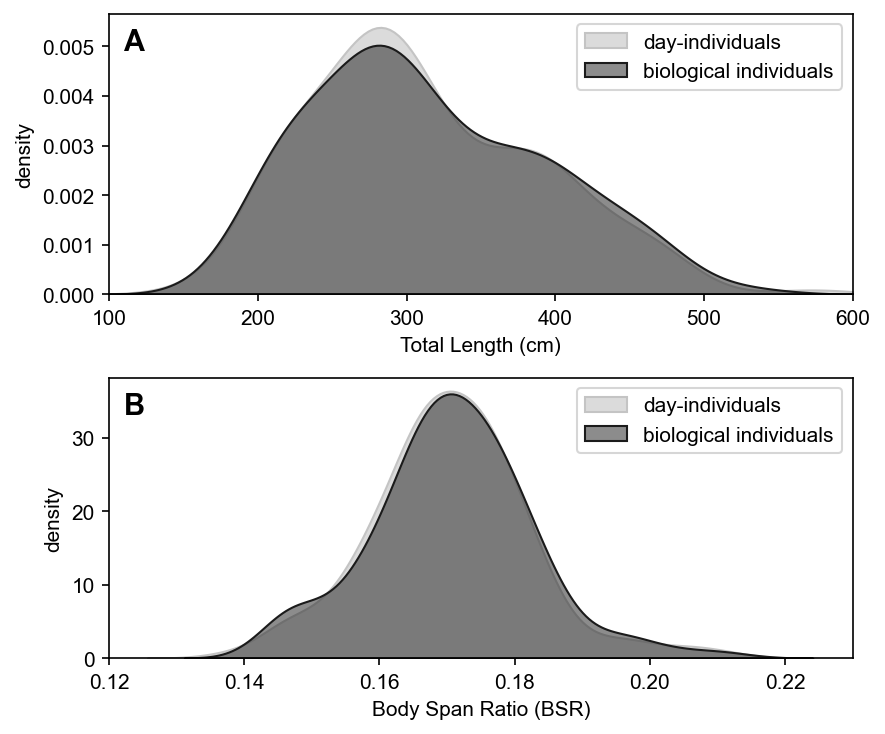

Figure saved as:
TIFF: /Volumes/JWS_2025/cv4e-bodycondition/sharkbody_seg/docs/figures/FigureS2.tiff


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(6, 5), dpi=150)

# --- Panel 1: TL_skel_cm ---
sns.kdeplot(df['TL_skel_cm'], fill=True, color="#C4C4C4", alpha=0.6, label='day-individuals', ax=axes[0])
sns.kdeplot(df_photog_reid['TL_skel_cm'], fill=True, color="#1B1B1B", alpha=0.5, label='biological individuals', ax=axes[0])
axes[0].set_xlabel('Total Length (cm)')
axes[0].set_ylabel('density')
axes[0].set_xlim(100, 600)
axes[0].legend()
axes[0].text(0.02, 0.95, 'A', transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')

# --- Panel 2: BSR_skel ---
sns.kdeplot(df['BSR_skel'], fill=True, color="#C4C4C4", alpha=0.6, label='day-individuals', ax=axes[1])
sns.kdeplot(df_photog_reid['BSR_skel'], fill=True, color="#1B1B1B", alpha=0.5, label='biological individuals', ax=axes[1])
axes[1].set_xlabel('Body Span Ratio (BSR)')
axes[1].set_ylabel('density')
axes[1].set_xlim(0.12, 0.23)
axes[1].legend()
axes[1].text(0.02, 0.95, 'B', transform=axes[1].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

tiff_path = f"{figure_dir}/FigureS2.tiff"
fig.savefig(tiff_path, dpi=300, bbox_inches="tight")
print(f"Figure saved as:\nTIFF: {tiff_path}")


## Visual Comparisons

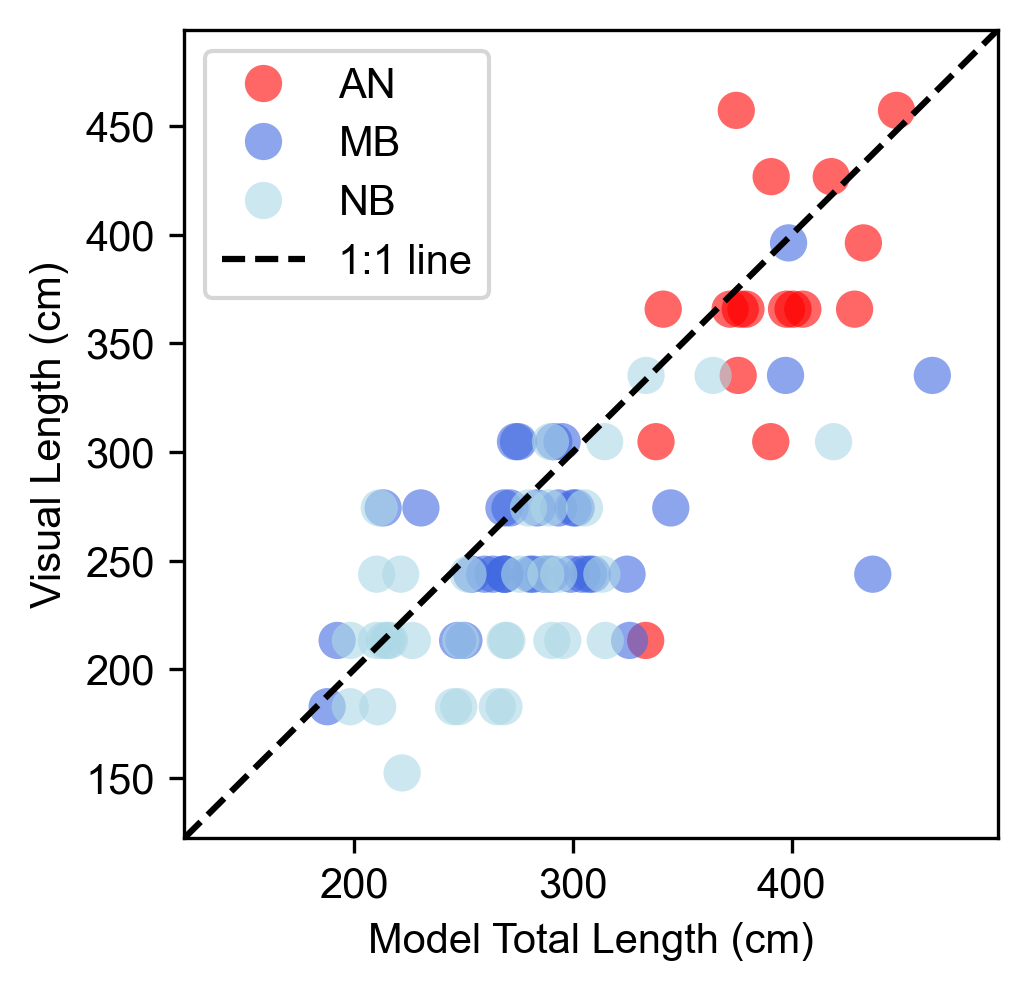

Mean difference between UAS (rounded) and visual estimates is 28.79 cm.
Pearson correlation: r = 0.776, p-value = 4.58e-19
n = 89


In [24]:
# bin mask data
#df['TL_skel_cm_rounded'] = (df['TL_skel_cm'] / 15.24).round() * 15.24

df_vis = df.dropna(subset=['VisualLength_cm'])

# Compute shared axis limits from filtered data
min_val = min(df_vis['VisualLength_cm'].min(), df_vis['TL_skel_cm'].min()) - 30 # px buffer
max_val = max(df_vis['VisualLength_cm'].max(), df_vis['TL_skel_cm'].max()) + 30

plt.figure(figsize=(3.5,3.5), dpi=300)  # higher dpi improves text clarity and sizing
sns.scatterplot(data=df_vis,x='TL_skel_cm',y='VisualLength_cm',hue='site',palette=site_colors,s=80,alpha=0.6,edgecolor='none')

# 1:1 reference line
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='1:1 line')

# Equal axis limits
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Labels and legend
plt.xlabel('Model Total Length (cm)')
plt.ylabel('Visual Length (cm)')
plt.legend(loc='upper left')
plt.show()

diffs = df_vis['TL_skel_cm'] - df_vis['VisualLength_cm']
mean_diff = np.mean(diffs)
print(f"Mean difference between UAS (rounded) and visual estimates is {mean_diff:.2f} cm.")
clean_df = df.dropna(subset=['TL_skel_cm', 'VisualLength_cm'])
r_value, p_value = pearsonr(clean_df['TL_skel_cm'], clean_df['VisualLength_cm'])
print(f"Pearson correlation: r = {r_value:.3f}, p-value = {p_value:.3g}")
print(f"n = {len(clean_df)}")


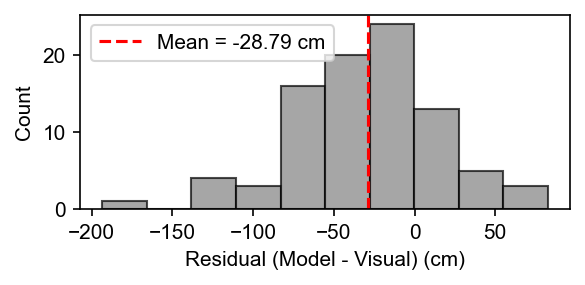

Sample size (n): 89
Mean residual: -28.79 cm
Standard deviation of residuals: 44.78 cm


In [25]:
# compute residuals
residuals = df['VisualLength_cm'] - df['TL_skel_cm'] 
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
n = residuals.dropna().shape[0]

# plot
plt.figure(figsize=(4, 2), dpi=150)
plt.hist(residuals, bins=10, color='gray', edgecolor='black', alpha=0.7)
plt.axvline(mean_residual, color='red', linestyle='--', label=f'Mean = {mean_residual:.2f} cm')
plt.xlabel('Residual (Model - Visual) (cm)')
plt.ylabel('Count')
#plt.title('Histogram of Residuals')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Sample size (n): {n}")
print(f"Mean residual: {mean_residual:.2f} cm")
print(f"Standard deviation of residuals: {std_residual:.2f} cm")

## Site Distribution

In [40]:
def run_tests(df, sex=None):
    if sex:
        print(f"\n--- Testing for sex: {sex} ---")
        df = df[df['sex'] == sex]
    else:
        print("\n--- Testing for all sexes combined ---")

    # normality check per site
    print("\nNormality test (Shapiro-Wilk) by site:")
    for site in df['site'].unique():
        lengths = df[df['site'] == site]['TL_skel_cm'].dropna()
        if len(lengths) >= 3:  # Shapiro needs at least 3 samples
            stat, p = shapiro(lengths)
            print(f"  {site}: p = {p:.4f} {'(non-normal)' if p < 0.05 else '(normal)'}")
        else:
            print(f"  {site}: Not enough data for test")

    # homogeneity of variance
    groups = [group['TL_skel_cm'].dropna().values for _, group in df.groupby('site')]
    stat, p = levene(*groups)
    print(f"\nLevene’s test for equal variance: p = {p:.4f} {'(heteroscedastic)' if p < 0.05 else '(homoscedastic)'}")

    # Kruskal-Wallis test
    stat, p = kruskal(*groups)
    print(f"\nKruskal-Wallis test across sites: H = {stat:.3f}, p = {p:.4g} {'(significant)' if p < 0.05 else '(not significant)'}")

    # Pairwise Mann-Whitney U tests with Bonferroni correction
    print("\nPairwise Mann-Whitney U tests (Bonferroni corrected):")
    sites = df['site'].unique()
    results = []
    n_tests = 0
    for site1, site2 in combinations(sites, 2):
        group1 = df[df['site'] == site1]['TL_skel_cm'].dropna()
        group2 = df[df['site'] == site2]['TL_skel_cm'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            n_tests += 1

    for site1, site2 in combinations(sites, 2):
        group1 = df[df['site'] == site1]['TL_skel_cm'].dropna()
        group2 = df[df['site'] == site2]['TL_skel_cm'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            p_corr = min(p * n_tests, 1.0)
            sig = 'Significant' if p_corr < 0.05 else 'Not significant'
            results.append({'Comparison': f'{site1} vs {site2}', 'p_raw': p, 'p_bonferroni': p_corr, 'Result': sig})

    for r in results:
        print(f"  {r['Comparison']}: raw p = {r['p_raw']:.4g}, Bonferroni p = {r['p_bonferroni']:.4g} → {r['Result']}")

# Run for all sexes combined
run_tests(df)


--- Testing for all sexes combined ---

Normality test (Shapiro-Wilk) by site:
  AN: p = 0.0975 (normal)
  MB: p = 0.0453 (non-normal)
  NB: p = 0.0308 (non-normal)

Levene’s test for equal variance: p = 0.9349 (homoscedastic)

Kruskal-Wallis test across sites: H = 80.178, p = 3.887e-18 (significant)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  AN vs MB: raw p = 1.569e-13, Bonferroni p = 4.706e-13 → Significant
  AN vs NB: raw p = 4.687e-15, Bonferroni p = 1.406e-14 → Significant
  MB vs NB: raw p = 0.000384, Bonferroni p = 0.001152 → Significant


In [41]:
# Run for females only
run_tests(df, sex='F')


--- Testing for sex: F ---

Normality test (Shapiro-Wilk) by site:
  AN: p = 0.0276 (non-normal)
  MB: p = 0.0381 (non-normal)
  NB: p = 0.5649 (normal)

Levene’s test for equal variance: p = 0.8259 (homoscedastic)

Kruskal-Wallis test across sites: H = 43.031, p = 4.528e-10 (significant)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  AN vs MB: raw p = 8.505e-07, Bonferroni p = 2.551e-06 → Significant
  AN vs NB: raw p = 4.759e-09, Bonferroni p = 1.428e-08 → Significant
  MB vs NB: raw p = 0.002738, Bonferroni p = 0.008214 → Significant


In [42]:
# Run for males only
run_tests(df, sex='M')


--- Testing for sex: M ---

Normality test (Shapiro-Wilk) by site:
  AN: p = 0.8684 (normal)
  MB: p = 0.2520 (normal)
  NB: p = 0.2355 (normal)

Levene’s test for equal variance: p = 0.8045 (homoscedastic)

Kruskal-Wallis test across sites: H = 26.997, p = 1.373e-06 (significant)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  AN vs MB: raw p = 5.494e-06, Bonferroni p = 1.648e-05 → Significant
  AN vs NB: raw p = 6.331e-05, Bonferroni p = 0.0001899 → Significant
  MB vs NB: raw p = 0.0479, Bonferroni p = 0.1437 → Not significant


In [43]:
# site distributions 
tl_stats = df.groupby('site')['TL_skel_cm'].agg(['mean', 'std']).reset_index()
tl_stats['mean_sd'] = tl_stats.apply(lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1)

print(tl_stats)


  site        mean        std         mean_sd
0   AN  408.426487  50.657441  408.43 ± 50.66
1   MB  297.417405  55.610189  297.42 ± 55.61
2   NB  262.676877  51.024861  262.68 ± 51.02


In [44]:
sst_stats = df_sst.groupby('site')['sst_c'].agg(['mean', 'std']).reset_index()
sst_stats['mean_sd'] = sst_stats.apply(lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1)

print(sst_stats)

  site       mean       std       mean_sd
0   AN  12.650000  1.157008  12.65 ± 1.16
1   MB  16.044000  1.516322  16.04 ± 1.52
2   NB  18.506667  1.181081  18.51 ± 1.18


/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_18562/1714800393.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sst, y="site", x="sst_c", palette=site_colors, width=0.6, fliersize=0, ax=ax3)
/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_18562/1714800393.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_sst, y="site", x="sst_c", palette=site_colors,
/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_18562/1714800393.py:136: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default 

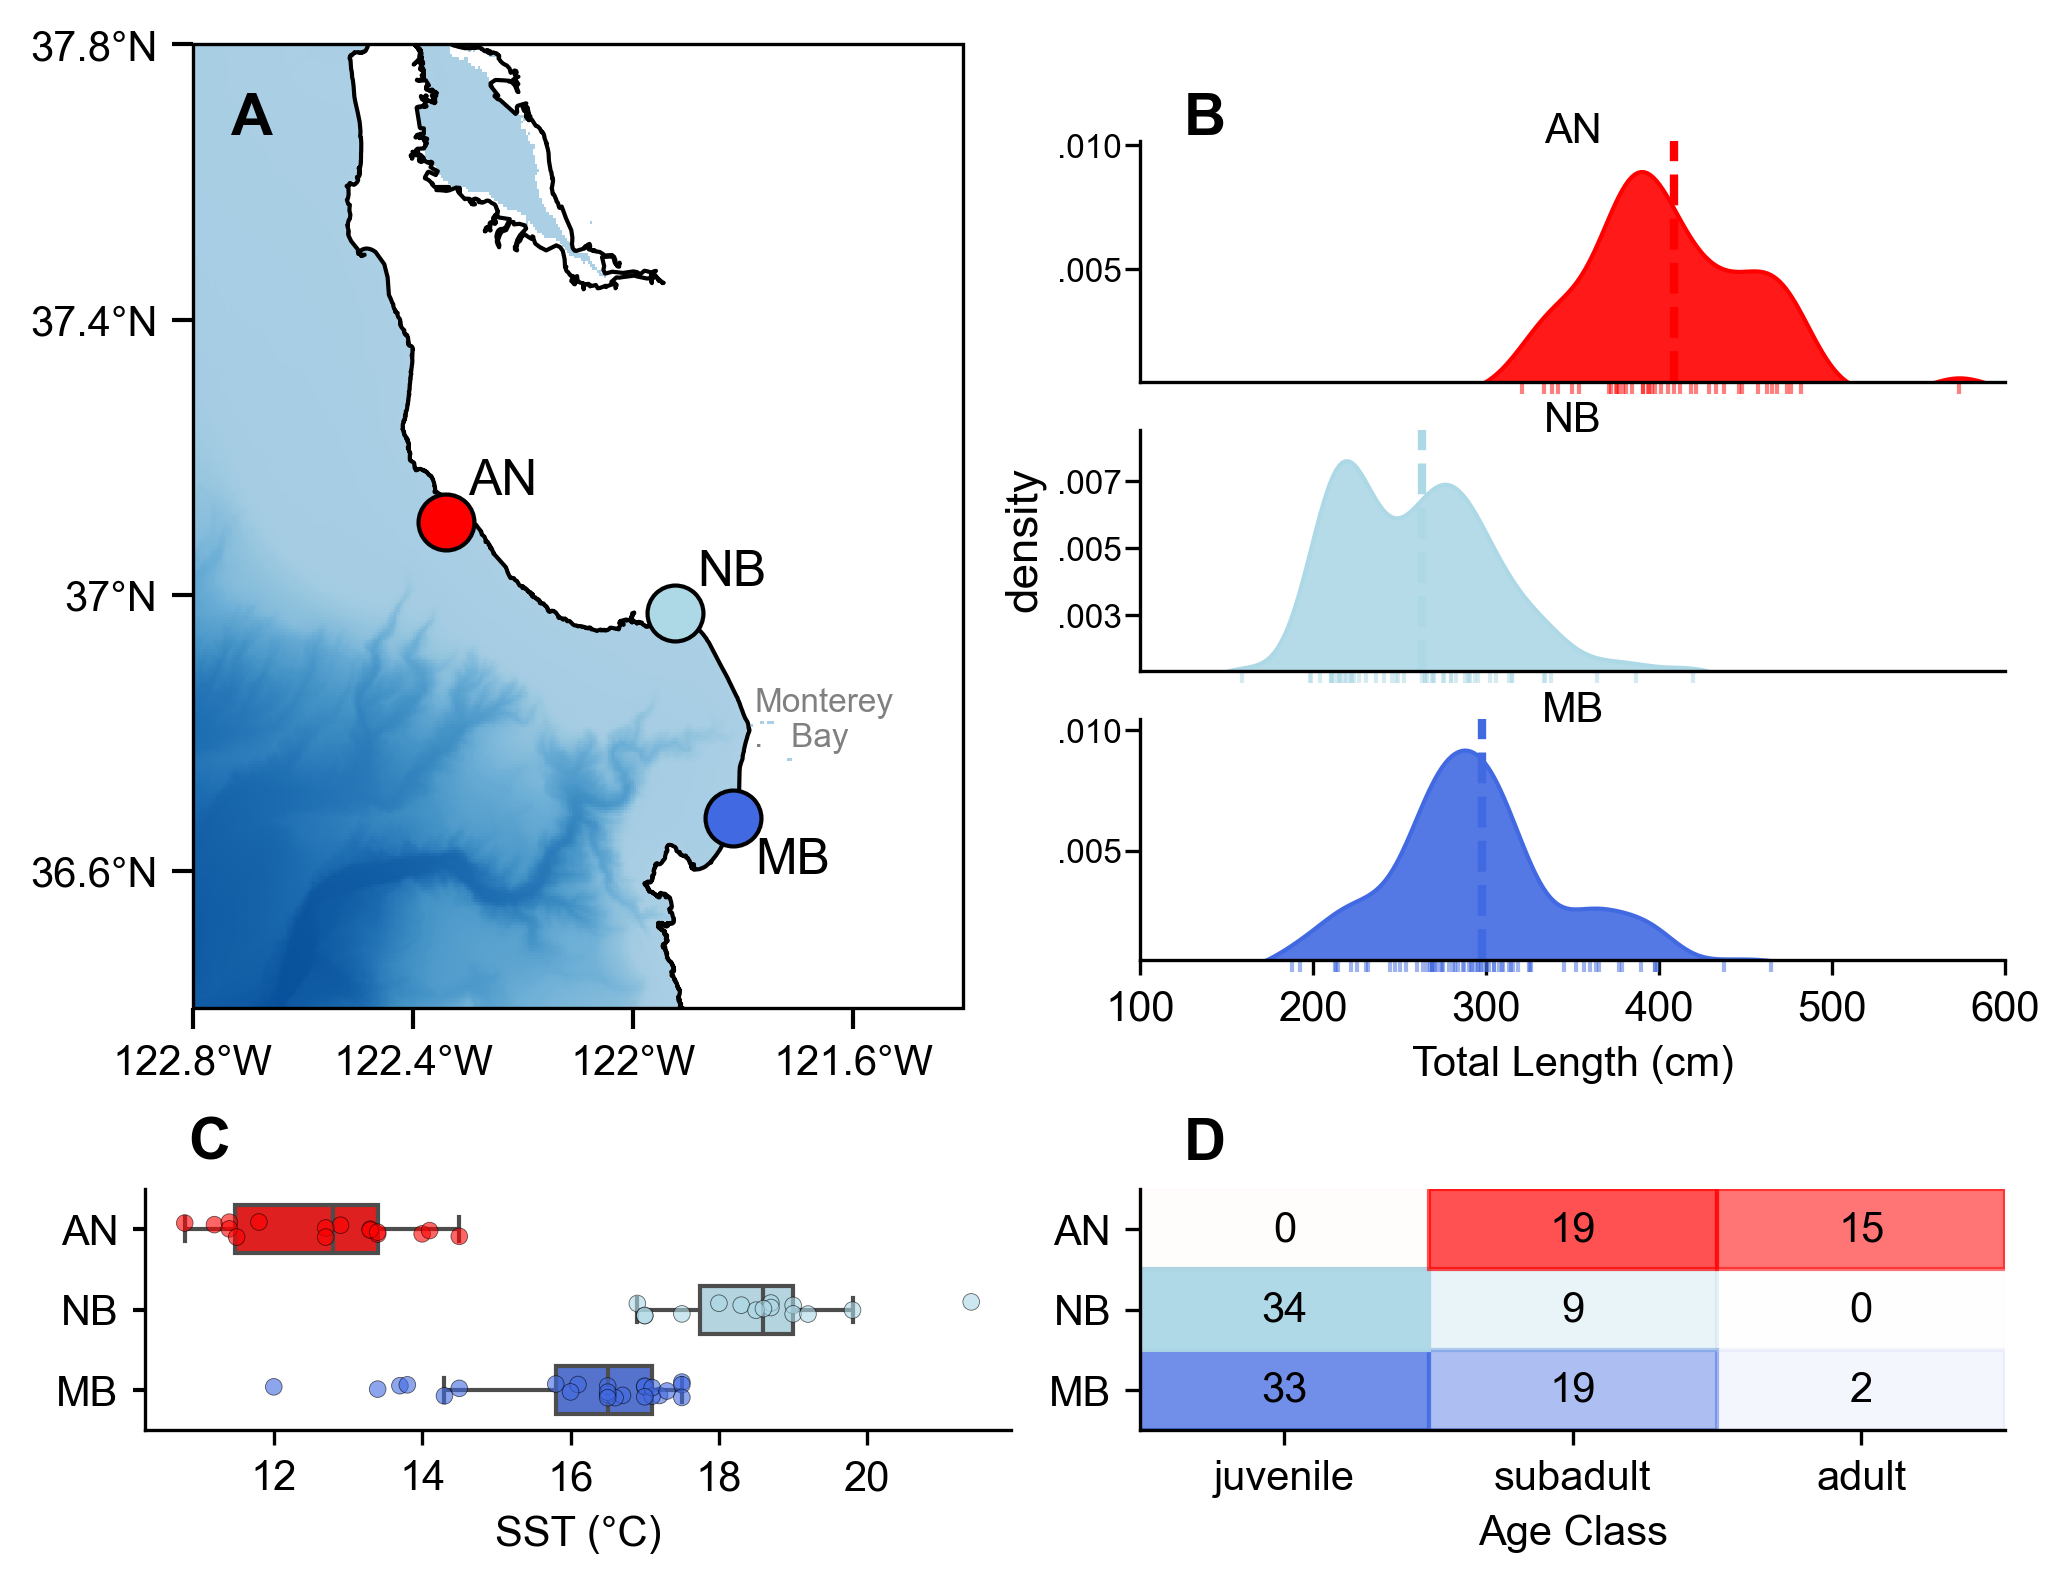

In [45]:
fig = plt.figure(figsize=(8, 6), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[4, 1],
                       hspace=0.3, wspace=0.15)

# -----------------------------
# Panel 1: Map (upper left)
# -----------------------------
# load raster
src = rasterio.open(bathy_path)
etopo = src.read(1)
extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
etopo_ocean = np.where(etopo < -1, etopo, np.nan) # mask land and shallow water (≤ -1 m is ocean)
cmap = plt.get_cmap('Blues_r')

# site order
site_names = ["NB", "MB", "AN"]
site_coords = {"AN": (-122.339292, 37.106197),"NB": (-121.923820, 36.974399),"MB": (-121.818199, 36.676165)}
site_order = ["AN", "NB", "MB"]
df["site"] = pd.Categorical(df["site"], categories=site_order, ordered=True)
df_sst["site"] = pd.Categorical(df_sst["site"], categories=site_order, ordered=True)
df_sex["site"] = pd.Categorical(df_sex["site"], categories=site_order, ordered=True)

ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
# Map plotting code here, using ax1
im = ax1.imshow(etopo_ocean, origin='upper', extent=extent,cmap=cmap, vmin=-4000, vmax=2000,
                transform=ccrs.PlateCarree(),interpolation='nearest')
coastline.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1, zorder=2)

for name in site_order:
    lon, lat = site_coords[name]
    ax1.scatter(lon, lat, color=site_colors[name], s=180, zorder=5, edgecolor="black", linewidths=1)
    if name == "MB":  # custom offset
        ax1.text(lon + 0.04, lat - 0.08, name, fontsize=12, color='black')
    else:
        ax1.text(lon + 0.04, lat + 0.04, name, fontsize=12, color='black')

ax1.set_extent([-122.8, -121.4, 36.4, 37.8], crs=ccrs.PlateCarree())
ax1.set_xticks(np.arange(-122.8, -121.4, 0.4), crs=ccrs.PlateCarree())
ax1.set_yticks(np.arange(36.6, 37.85, 0.4), crs=ccrs.PlateCarree())
ax1.xaxis.set_major_formatter(LongitudeFormatter())
ax1.yaxis.set_major_formatter(LatitudeFormatter())
ax1.tick_params(top=False,right=False,bottom=True,left=True,direction='out', length=5,width=1,labelsize=10)

# Panel letter
ax1.text(0.05, 0.95, "A", transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')
ax1.text(-121.78, 36.78, "Monterey\n.   Bay",fontsize=8, 
        color='gray',transform=ccrs.PlateCarree(), zorder=6)

# -----------------------------
# Panel 2: TL KDE (upper right)
# -----------------------------
ax2 = fig.add_subplot(gs[0,1])
ax2.set_xticks([])
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

n_sites = len(site_order)
kde_height = 0.25
spacing = 0.05

for i, site in enumerate(site_order[::-1]):  # top = high latitude
    left = 0.0
    bottom = spacing + i * (kde_height + spacing)
    width = 1.0
    height = kde_height

    ax = ax2.inset_axes([left, bottom, width, height])

    # KDE and rug
    sns.kdeplot(data=df[df['site'] == site], x="TL_skel_cm",
                fill=True, alpha=0.9, bw_adjust=0.7,
                color=site_colors[site], ax=ax)
    sns.rugplot(data=df[df['site'] == site], x="TL_skel_cm",
                height=-0.05, clip_on=False, alpha=0.5, ax=ax, color=site_colors[site])
    
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.2) # add top padding

    # mean line
    mean_val = df.loc[df['site'] == site, 'TL_skel_cm'].mean()
    ax.axvline(mean_val, color=site_colors[site], linestyle='--', linewidth=2)

    # Styling
    ax.set_xlim(100, 600)
    ax.set_ylabel("")  # remove y-axis labels

    # only bottom-most axis shows x-axis label
    if i == 0:
        ax.set_xlabel("Total Length (cm)")
        ax.tick_params(left=True, bottom=True, labelbottom=True)
    else:
        ax.set_xlabel("")
        ax.tick_params(left=True, bottom=False, labelbottom=False)

    sns.despine(ax=ax, top=True, right=True)

    # compact y axis 
    ax.tick_params(axis='y', labelsize=8, pad=1)  # smaller font, less padding
    ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.3f}".lstrip("0")))

    # add site label above each curve
    ax.text(0.5, 0.96, site, transform=ax.transAxes, ha='center', va='bottom', fontsize=10)


# Panel letter
ax.set_ylabel("density", fontsize=11, labelpad=5)
ax.yaxis.set_label_coords(-0.11, -0.65)

ax2.text(0.05, 0.95, "B", transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# -----------------------------
# Panel 3: SST (lower left)
# -----------------------------
ax3 = fig.add_subplot(gs[1,0])
sns.boxplot(data=df_sst, y="site", x="sst_c", palette=site_colors, width=0.6, fliersize=0, ax=ax3)
sns.stripplot(data=df_sst, y="site", x="sst_c", palette=site_colors,
              dodge=False, alpha=0.6,jitter=0.1, linewidth=0.2, edgecolor="black", size=4, ax=ax3)
ax3.set_xlabel("SST (°C)")
ax3.set_ylabel("")
sns.despine(ax=ax3, top=True, right=True)
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(axis='y', which='both', length=3, width=1, direction='out')

# Panel letter
ax3.text(0.05, 1.3, "C", transform=ax3.transAxes, fontsize=14, fontweight='bold', va='top')

# -----------------------------
# Panel 4: Age class composition (lower right)
# -----------------------------
ax4 = fig.add_subplot(gs[1,1])

count_table = df_sex.groupby(['site', 'ageclass']).size().unstack(fill_value=0).reindex(site_order[::-1])
proportion_table = count_table.div(count_table.sum(axis=1), axis=0)

for i, site in enumerate(count_table.index):
    base_rgb = mcolors.to_rgb(site_colors.get(site, 'gray'))
    for j, ageclass in enumerate(count_table.columns):
        opacity = min(1, 0.01 + 1.2 * proportion_table.loc[site, ageclass])
        rgba = base_rgb + (opacity,)
        ax4.add_patch(plt.Rectangle((j, i), 1, 1, color=rgba, edgecolor='none'))
        count = count_table.loc[site, ageclass]
        ax4.text(j + 0.5, i + 0.5, str(count), ha='center', va='center', color='black')

ax4.set_xticks(np.arange(len(count_table.columns)) + 0.5)
ax4.set_xticklabels(count_table.columns)
ax4.set_yticks(np.arange(len(count_table.index)) + 0.5)
ax4.set_yticklabels(count_table.index)
ax4.invert_yaxis()
ax4.set_ylabel("")
ax4.xaxis.tick_bottom()
ax4.set_xlabel('Age Class')
for spine in ax4.spines.values():
    spine.set_visible(False)
ax4.spines['bottom'].set_visible(True)
ax4.spines['left'].set_visible(True)
ax4.set_xlim(0, len(count_table.columns))
ax4.set_ylim(0, len(count_table.index))

# Panel letter
ax4.text(0.05, 1.3, "D", transform=ax4.transAxes, fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.show()


# Scaling Relationships

In [46]:
# Prep comparison for Logan et al. 2018 scaling relationships 

# girth
b_logan, b_low, b_high  = -14.09, -21.4, -6.81 # 95% CI
a_logan, a_low, a_high = 0.59, 0.55, 0.64 # 95% CI

a_span = a_logan/(np.pi) # convert circumference to diameter
b_span = b_logan/(np.pi)

# convert UAS data - lateral span (diameter) to girth metrics (circumference)
df['FS_circumference_cm'] = df['FS_skel_cm']*np.pi
df_sex['FS_circumference_cm'] = df_sex['FS_skel_cm']*np.pi

# mass
a_mass, a_mass_low, a_mass_high= 3.85e-6, 0.13e-5, 1.11e-5
b_mass, b_mass_low, b_mass_high = 3.18, 2.97, 3.39

# apply to UAS data - mass predictions
df['est_mass_kg'] = a_mass * (df['TL_skel_cm'] ** b_mass)

In [47]:
# Prep comparison for Hunt et a. 2024 scaling relationships 

# regression coefficients; converted pcl -> tl, mm -> cm
a_orig = (-0.49675 + (math.log(10)*-0.03195))
b_hunt = (0.95*1.019)

# convert to non-logged diameter (eqn: g1d = a * tl**b)
a_hunt = math.e**a_orig

In [48]:
# Mollet & Calliet 1996

# regression coefficients; convert pcl -> tl, m -> cm
b_mollet = ((-0.169) + (0.686*-0.095))*100
a_mollet = (0.686*0.8550)

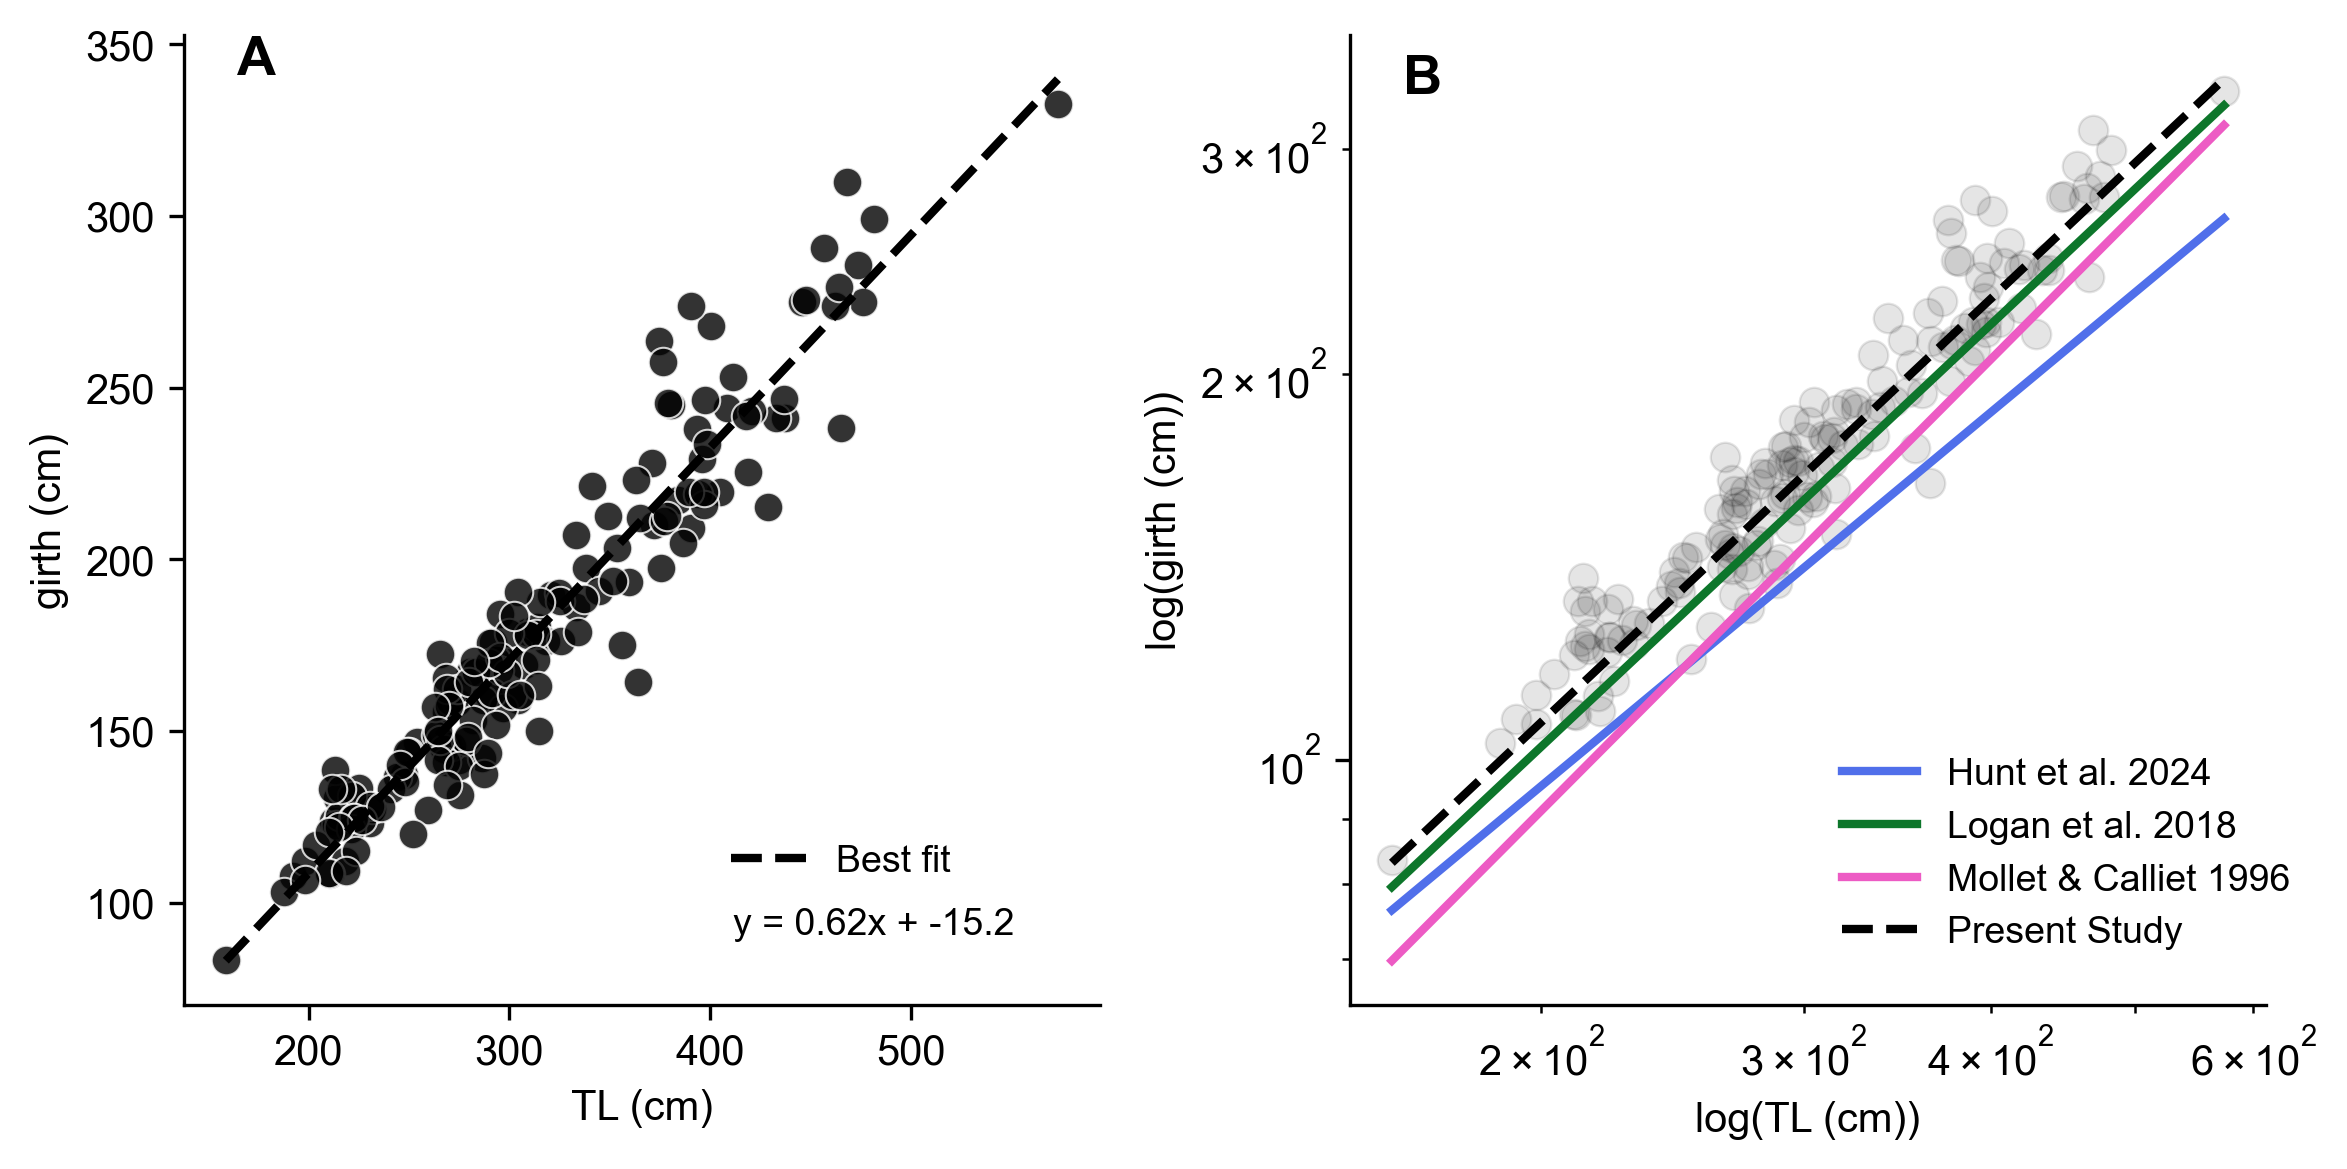

In [49]:
# Compute linear best fit for your data
x_vals = np.array([df['TL_skel_cm'].min(), df['TL_skel_cm'].max()])
slope, intercept, r_value, p_value, std_err = linregress(df['TL_skel_cm'], df['FS_circumference_cm'])
y_vals = slope * x_vals + intercept

# Compute reference lines
y_hunt = a_hunt * (x_vals ** b_hunt)
y_central = b_logan + a_logan * x_vals
y_mollet = b_mollet + a_mollet * x_vals

# Set up figure with 2 panels
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# scatter + linear best fit
sns.scatterplot(data=df, x='TL_skel_cm', y='FS_circumference_cm',
    color='black', s=50, edgecolor='white', linewidth=0.5, alpha=0.8, ax=axes[0])

axes[0].plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label='Best fit')

bestfit_eq = f'y = {slope:.2f}x + {intercept:.1f}'

axes[0].text(0.6, 0.1, bestfit_eq, transform=axes[0].transAxes,fontsize=9, color='black', verticalalignment='top')

# panel A
axes[0].text(0.1, 1.0, 'A', transform=axes[0].transAxes,
             fontsize=13, fontweight='bold', va='top', ha='right')

axes[0].set_xlabel('TL (cm)')
axes[0].set_ylabel('girth (cm)')
axes[0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.56, 0.2), fontsize=9)

#  reference lines + faint data on log-log axes 

# scatter lightly
sns.scatterplot(data=df, x='TL_skel_cm', y='FS_circumference_cm',
                color='black', s=50, alpha=0.1, ax=axes[1], edgecolor=None)

# reference lines
axes[1].plot(x_vals, y_hunt, color="#506FEA", linewidth=2, label='Hunt et al. 2024')
axes[1].plot(x_vals, y_central, color="#0D762B", linewidth=2, label='Logan et al. 2018')
axes[1].plot(x_vals, y_mollet, color="#ED5BC4", linewidth=2, label='Mollet & Calliet 1996')
axes[1].plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label='Present Study')

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('log(TL (cm))')
axes[1].set_ylabel('log(girth (cm))')
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 0.29), fontsize=9)

# panel b 
axes[1].text(0.1, 0.98, 'B', transform=axes[1].transAxes,
             fontsize=13, fontweight='bold', va='top', ha='right')

sns.despine()
plt.tight_layout()
plt.show()


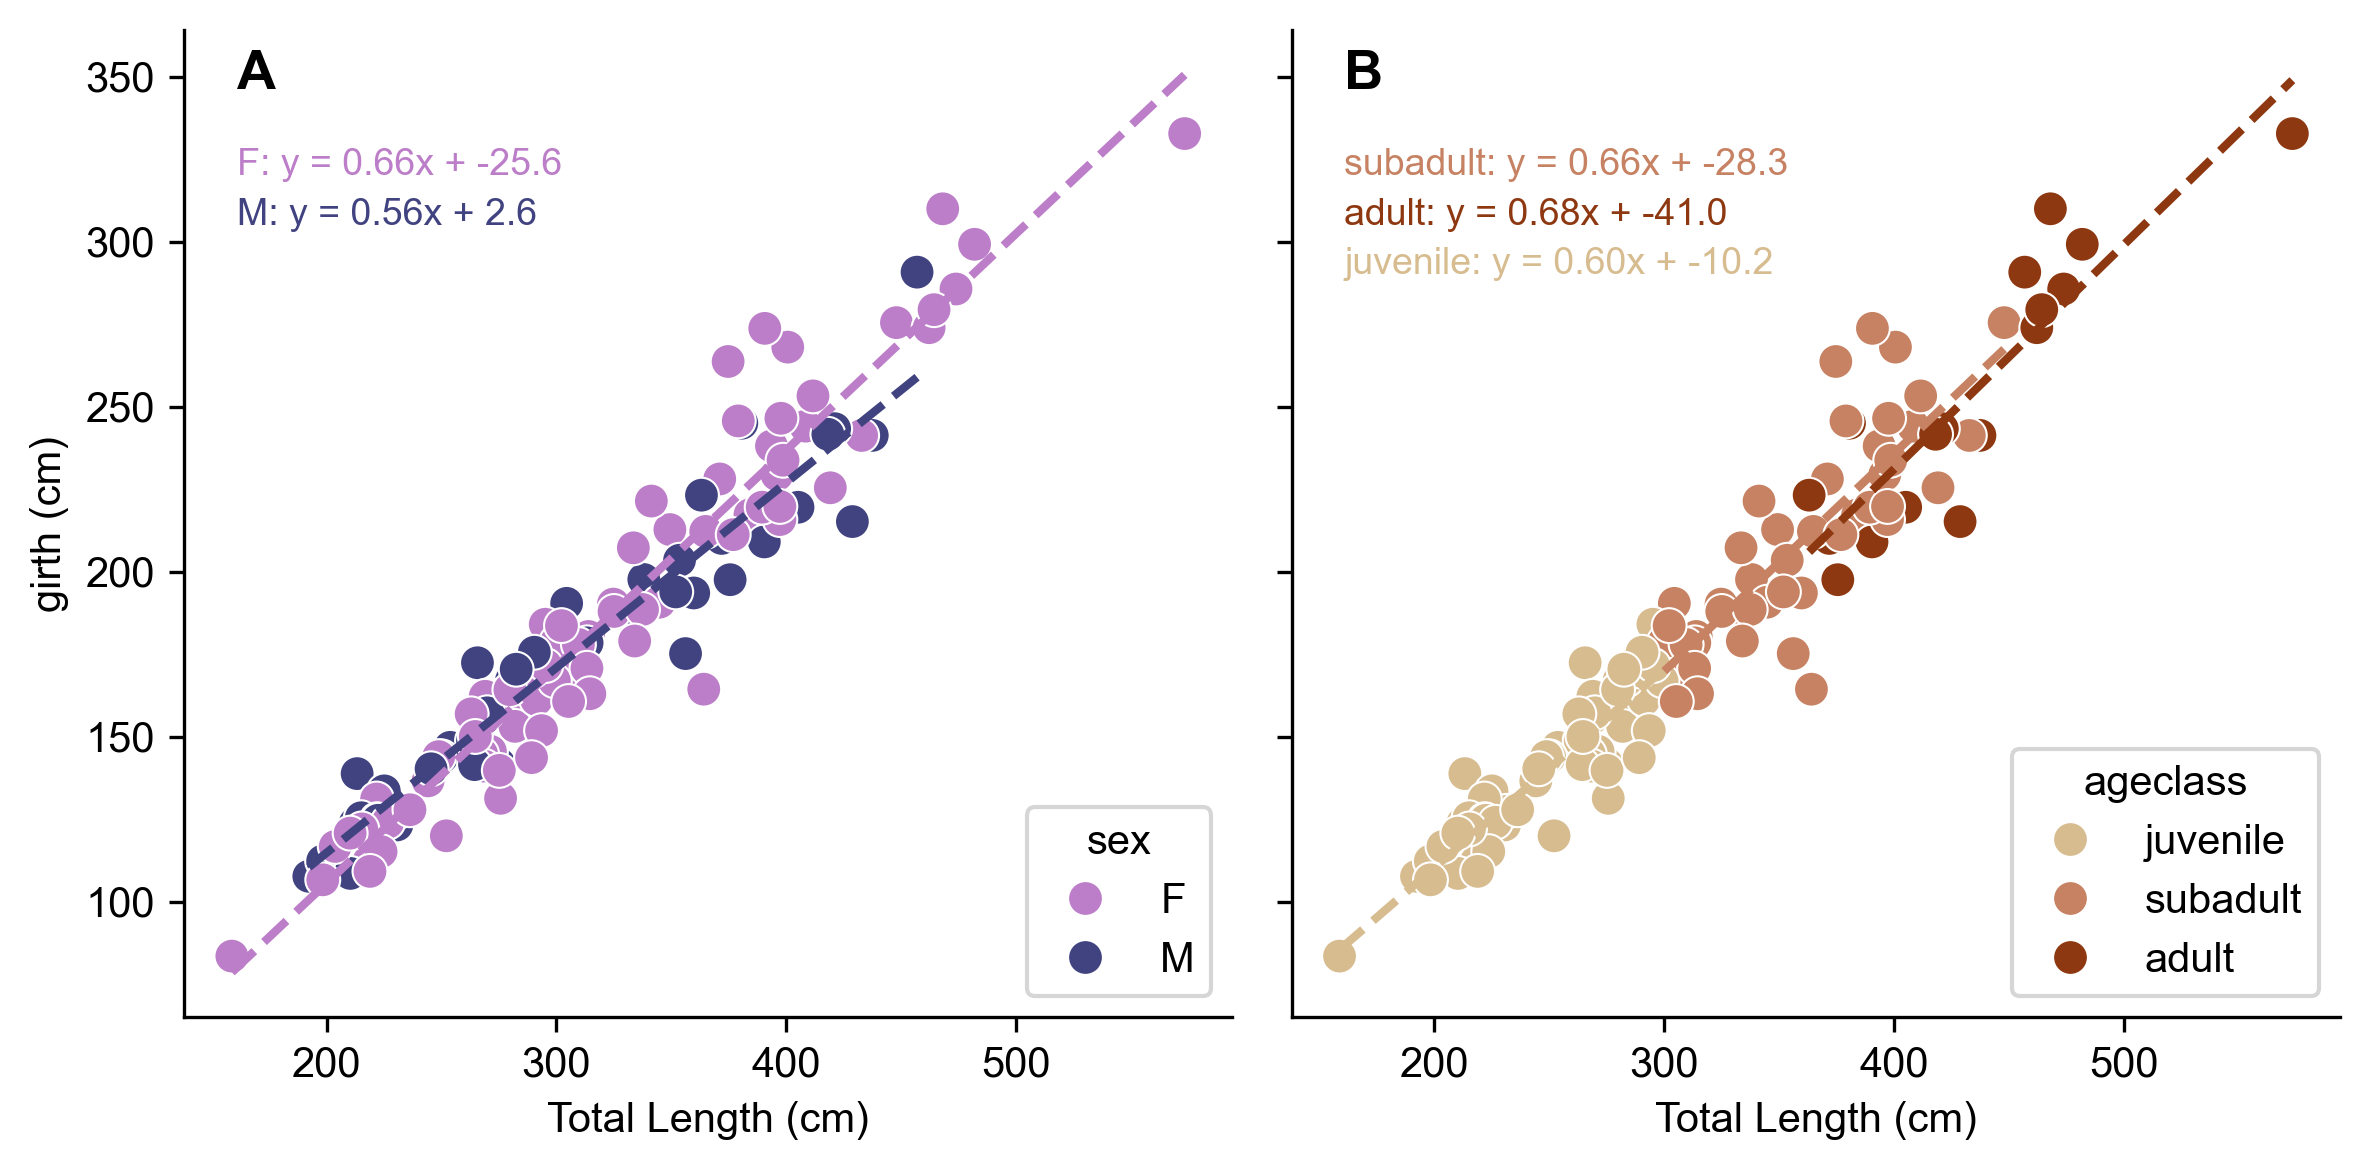

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300, sharey=True)

# by sex
sns.scatterplot(data=df_sex, x='TL_skel_cm', y='FS_circumference_cm', hue='sex',
                palette=sex_colors, s=70, edgecolor='white', linewidth=0.5, ax=axes[0])

for sex in df_sex['sex'].unique():
    subset = df_sex[df_sex['sex'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset['TL_skel_cm'], subset['FS_circumference_cm'])
    x_vals = np.array([subset['TL_skel_cm'].min(), subset['TL_skel_cm'].max()])
    y_vals = slope * x_vals + intercept
    axes[0].plot(x_vals, y_vals, color=sex_colors[sex], linestyle='--', linewidth=2,
                 label=f'{sex} best fit')

    eq_text = f'{sex}: y = {slope:.2f}x + {intercept:.1f}'
    axes[0].text(0.05, 0.88 if sex == 'F' else 0.83, eq_text, transform=axes[0].transAxes,
                 fontsize=9, color=sex_colors[sex], verticalalignment='top')
axes[0].set_xlabel('Total Length (cm)')
axes[0].set_ylabel('girth (cm)')
sns.despine(ax=axes[0])

# panel label A
axes[0].text(0.05, 0.98, 'A', transform=axes[0].transAxes,
             fontsize=13, fontweight='bold', va='top', ha='left')

# by age class
sns.scatterplot(data=df_sex, x='TL_skel_cm', y='FS_circumference_cm', hue='ageclass',
                palette=age_colors, s=70, edgecolor='white', linewidth=0.5, ax=axes[1])

for age in df_sex['ageclass'].unique():
    subset = df_sex[df_sex['ageclass'] == age]
    slope, intercept, r_value, p_value, std_err = linregress(subset['TL_skel_cm'], subset['FS_circumference_cm'])
    x_vals = np.array([subset['TL_skel_cm'].min(), subset['TL_skel_cm'].max()])
    y_vals = slope * x_vals + intercept
    axes[1].plot(x_vals, y_vals, color=age_colors[age], linestyle='--', linewidth=2,
                 label=f'{age} best fit')

    eq_text = f'{age}: y = {slope:.2f}x + {intercept:.1f}'
    age_list = df_sex['ageclass'].unique().tolist()
    ypos = 0.88 - 0.05 * age_list.index(age)
    axes[1].text(0.05, ypos, eq_text, transform=axes[1].transAxes,
                 fontsize=9, color=age_colors[age], verticalalignment='top')
axes[1].set_xlabel('Total Length (cm)')
axes[1].set_ylabel('')

# panel label B
axes[1].text(0.05, 0.98, 'B', transform=axes[1].transAxes,
             fontsize=13, fontweight='bold', va='top', ha='left')

sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()


In [51]:
span_summary = []
for m in ['FS_skel_cm', 'LS_skel_cm', 'PS_skel_cm']:
    subset = df[['TL_skel_cm', m]].dropna()
    slope, intercept, r_value, p_value, std_err = linregress(subset['TL_skel_cm'], subset[m])
    span_summary.append({
        'Measure': m,'Slope (a)': slope,'Intercept (B)': intercept,'R': r_value,'n': len(subset),'p_value': p_value})
summary_df = pd.DataFrame(span_summary)

sex_summary = []
for sex in df_sex['sex'].unique():
    subset = df_sex[df_sex['sex'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset['TL_skel_cm'], subset['BS_skel_cm'])
    sex_summary.append({
        'Group': sex,'Slope (a)': slope,'Intercept (B)': intercept,'R': r_value,'n': len(subset),'p_value': p_value})
sex_df = pd.DataFrame(sex_summary)

# ageclass
age_summary = []
for age in df_sex['ageclass'].unique():
    subset = df_sex[df_sex['ageclass'] == age]
    slope, intercept, r_value, p_value, std_err = linregress(subset['TL_skel_cm'], subset['BS_skel_cm'])
    age_summary.append({
        'Group': age,'Slope (a)': slope,'Intercept (B)': intercept,'R': r_value,'n': len(subset),'p_value': p_value})
age_df = pd.DataFrame(age_summary)

# girth
subset = df[['TL_skel_cm', 'FS_circumference_cm']].dropna()
slope, intercept, r_value, p_value, std_err = linregress(subset['TL_skel_cm'], subset['FS_circumference_cm'])
fs_circ_summary = {
    'Measure': 'FS_circumference_cm','Slope (a)': slope,'Intercept (B)': intercept,'R': r_value,'n': len(subset),'p_value': p_value}
girth_df = pd.DataFrame([fs_circ_summary])

print("\n--- Span Regression Summary ---")
print(summary_df)

print("\n--- Sex Regression Summary ---")
print(sex_df.to_string(index=False))

print("\n--- Age Class Regression Summary ---")
print(age_df.to_string(index=False))

print("\n--- Girth Regression Summary ---")
print(girth_df.to_string(index=False))


--- Span Regression Summary ---
      Measure  Slope (a)  Intercept (B)         R    n       p_value
0  FS_skel_cm   0.197134      -4.841639  0.958197  163  2.078448e-89
1  LS_skel_cm   0.183857      -2.923117  0.966621  163  3.947901e-97
2  PS_skel_cm   0.165626      -2.931859  0.942165  163  2.437146e-78

--- Sex Regression Summary ---
Group  Slope (a)  Intercept (B)        R  n      p_value
    F   0.192806      -6.597741 0.969099 85 3.165624e-52
    M   0.166042       1.465725 0.974061 46 4.936115e-30

--- Age Class Regression Summary ---
   Group  Slope (a)  Intercept (B)        R  n      p_value
subadult   0.195866      -7.979249 0.850681 47 3.734668e-14
   adult   0.203948     -12.721836 0.931952 17 5.303414e-08
juvenile   0.168567       0.058043 0.924901 67 5.345550e-29

--- Girth Regression Summary ---
            Measure  Slope (a)  Intercept (B)        R   n      p_value
FS_circumference_cm   0.619316     -15.210457 0.958197 163 2.078448e-89


In [52]:
# statistics: parametric tests

# sex
model_sex = smf.ols('BS_skel_cm ~ TL_skel_cm * sex', data=df_sex).fit()
anova_sex = sm.stats.anova_lm(model_sex, typ=2)
print("ANCOVA for sex:")
print(anova_sex)

# Age class
model_age = smf.ols('BS_skel_cm ~ TL_skel_cm * ageclass', data=df_sex).fit()
anova_age = sm.stats.anova_lm(model_age, typ=2)
print("\nANCOVA for age class:")
print(anova_age)

# assumption checks

# sex - residuals
sex_residuals = model_sex.resid

shapiro_sex = stats.shapiro(sex_residuals)
print(f"Shapiro-Wilk test (sex residuals): W={shapiro_sex.statistic:.3f}, p={shapiro_sex.pvalue:.3f}")

sex_groups = [df_sex.loc[df_sex['sex'] == g, 'BS_skel_cm'] for g in df_sex['sex'].unique()]
levene_sex = stats.levene(*sex_groups)
print(f"Levene’s test (sex groups): W={levene_sex.statistic:.3f}, p={levene_sex.pvalue:.3f}")


# age - residuals
age_residuals = model_age.resid

shapiro_age = stats.shapiro(age_residuals)
print(f"Shapiro-Wilk test (age residuals): W={shapiro_age.statistic:.3f}, p={shapiro_age.pvalue:.3f}")

age_groups = [df_sex.loc[df_sex['ageclass'] == g, 'BS_skel_cm'] for g in df_sex['ageclass'].unique()]
levene_age = stats.levene(*age_groups)
print(f"Levene’s test (age classes): W={levene_age.statistic:.3f}, p={levene_age.pvalue:.3f}")

ANCOVA for sex:
                      sum_sq     df            F        PR(>F)
sex                 1.018136    1.0     0.079966  7.778039e-01
TL_skel_cm      25936.945114    1.0  2037.128799  4.604316e-80
TL_skel_cm:sex    117.319529    1.0     9.214462  2.913640e-03
Residual         1616.977793  127.0          NaN           NaN

ANCOVA for age class:
                          sum_sq     df           F        PR(>F)
ageclass                3.252799    2.0    0.120411  8.866588e-01
TL_skel_cm           6679.295657    1.0  494.503362  2.849968e-45
TL_skel_cm:ageclass    43.677864    2.0    1.616851  2.026467e-01
Residual             1688.384796  125.0         NaN           NaN
Shapiro-Wilk test (sex residuals): W=0.960, p=0.001
Levene’s test (sex groups): W=2.171, p=0.143
Shapiro-Wilk test (age residuals): W=0.957, p=0.000
Levene’s test (age classes): W=8.447, p=0.000


In [53]:
# statistics - nonparametric tests given evidence of non-normality and unequal variance

# gls - sex
group_vars_sex = df_sex.groupby("sex")["BS_skel_cm"].var()
w_sex = df_sex["sex"].map(group_vars_sex)  # variance by group

gls_sex = smf.gls("BS_skel_cm ~ TL_skel_cm * sex", data=df_sex, sigma=w_sex).fit()
print("GLS model (Sex):")
print(gls_sex.summary())


# gls - age class
group_vars_age = df_sex.groupby("ageclass")["BS_skel_cm"].var()
w_age = df_sex["ageclass"].map(group_vars_age)

gls_age = smf.gls("BS_skel_cm ~ TL_skel_cm * ageclass", data=df_sex, sigma=w_age).fit()
print("\nGLS model (Age Class):")
print(gls_age.summary())


GLS model (Sex):
                            GLS Regression Results                            
Dep. Variable:             BS_skel_cm   R-squared:                       0.943
Model:                            GLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     706.9
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           5.01e-79
Time:                        18:49:28   Log-Likelihood:                -347.76
No. Observations:                 131   AIC:                             703.5
Df Residuals:                     127   BIC:                             715.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept        

/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_18562/582461323.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_vars_age = df_sex.groupby("ageclass")["BS_skel_cm"].var()


# Whole-Body Body Condition Ratio

Most variable width exploration

In [54]:
summary = df['BSR_skel'].agg(['mean', 'std', 'min', 'max']).to_frame().T
summary['range'] = summary['max'] - summary['min']
summary

,mean,std,min,max,range
BSR_skel,0.170355,0.011719,0.138351,0.210788,0.072438


In [80]:
site_colors = {'NB': 'lightblue', 'MB': 'royalblue', 'AN': 'red'}

# width cols 
width_cols = [col for col in df_width_id.columns if col.startswith('width_')]
df_long = df_width_id.melt(id_vars=['TL_skel_cm', 'site', 'sex'], value_vars=width_cols, var_name='width', value_name='span_cm')
df_long['span_ratio'] = df_long['span_cm'] / df_long['TL_skel_cm']

# compute cv of spans
site_mean_df = df_long.groupby(['width', 'site'])['span_ratio'].mean().reset_index()
site_mean_df.columns = ['width', 'site', 'sitemean']

# width to percent
width_to_percent = {col: f"{5 + i*5}%" for i, col in enumerate(width_cols)}
df_long['width_percent'] = df_long['width'].map(width_to_percent)
site_mean_df['width_percent'] = site_mean_df['width'].map(width_to_percent)

In [81]:
span_summary = (
    df_long.groupby('width_percent')['span_cm']
    .agg(['mean', 'std']).reset_index().sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_span_cm', 'std': 'sd_span_cm'}))

df_long['span_ratio'] = df_long['span_cm'] / df_long['TL_skel_cm']

ratio_summary = (
    df_long.groupby('width_percent')['span_ratio']
    .agg(['mean', 'std']).reset_index().rename(columns={'mean': 'mean_span_ratio', 'std': 'sd_span_ratio'}))

mean_summary = span_summary.merge(ratio_summary, on='width_percent')
mean_summary

,width_percent,mean_span_cm,sd_span_cm,mean_span_ratio,sd_span_ratio
0,35%,58.448953,15.922442,0.186504,0.012622
1,30%,57.547554,15.369576,0.183831,0.011786
2,40%,56.714690,15.833216,0.180797,0.013926
3,25%,54.487312,14.638135,0.174076,0.011738
4,45%,53.037498,14.938767,0.169159,0.014922
5,20%,49.628220,13.164995,0.158742,0.011955
6,50%,48.785812,13.528926,0.155784,0.013682
7,55%,44.711156,12.013312,0.143089,0.012430
8,15%,42.866280,11.234737,0.137409,0.012588
9,60%,41.052303,10.704500,0.131629,0.011475


In [82]:
ratio_summary = (
    df_long.groupby('width_percent')['span_ratio']
    .agg(['mean', 'min', 'max', 'std']).reset_index().rename(columns={'mean': 'mean_span_ratio', 'std':'std_span_ratio'}))

ratio_summary['range_span_ratio'] = ratio_summary['max'] - ratio_summary['min']
ratio_summary = ratio_summary.sort_values('std_span_ratio', ascending=False)
ratio_summary

,width_percent,mean_span_ratio,min,max,std_span_ratio,range_span_ratio
15,80%,0.081865,0.036037,0.133503,0.017275,0.097466
16,85%,0.053594,0.025015,0.126302,0.015646,0.101288
0,10%,0.107133,0.065625,0.170159,0.015424,0.104534
7,45%,0.169159,0.128081,0.214914,0.014922,0.086833
6,40%,0.180797,0.143704,0.223995,0.013926,0.080291
9,50%,0.155784,0.123170,0.199894,0.013682,0.076724
5,35%,0.186504,0.154111,0.229211,0.012622,0.075100
1,15%,0.137409,0.103438,0.183381,0.012588,0.079942
10,55%,0.143089,0.114361,0.183494,0.012430,0.069133
14,75%,0.102633,0.044824,0.139921,0.012054,0.095097


In [83]:
# filter to width_percent between 25% and 45%
df_span_midbody = df_long[df_long['width_percent'].isin(['25%', '30%', '35%', '40%', '45%'])]

# compute span summary
span_summary = (
    df_span_midbody.groupby('width_percent')['span_cm']
    .agg(['mean', 'std']).reset_index()
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_span_cm', 'std': 'sd_span_cm'}))

# compute span ratio
df_span_midbody['span_ratio'] = df_span_midbody['span_cm'] / df_span_midbody['TL_skel_cm']
ratio_summary = (
    df_span_midbody.groupby('width_percent')['span_ratio']
    .agg(['mean', 'std']).reset_index()
    .rename(columns={'mean': 'mean_span_ratio', 'std': 'sd_span_ratio'}))

mean_summary = span_summary.merge(ratio_summary, on='width_percent')
mean_summary


/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_18562/4051759442.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_span_midbody['span_ratio'] = df_span_midbody['span_cm'] / df_span_midbody['TL_skel_cm']


,width_percent,mean_span_cm,sd_span_cm,mean_span_ratio,sd_span_ratio
0,35%,58.448953,15.922442,0.186504,0.012622
1,30%,57.547554,15.369576,0.183831,0.011786
2,40%,56.714690,15.833216,0.180797,0.013926
3,25%,54.487312,14.638135,0.174076,0.011738
4,45%,53.037498,14.938767,0.169159,0.014922


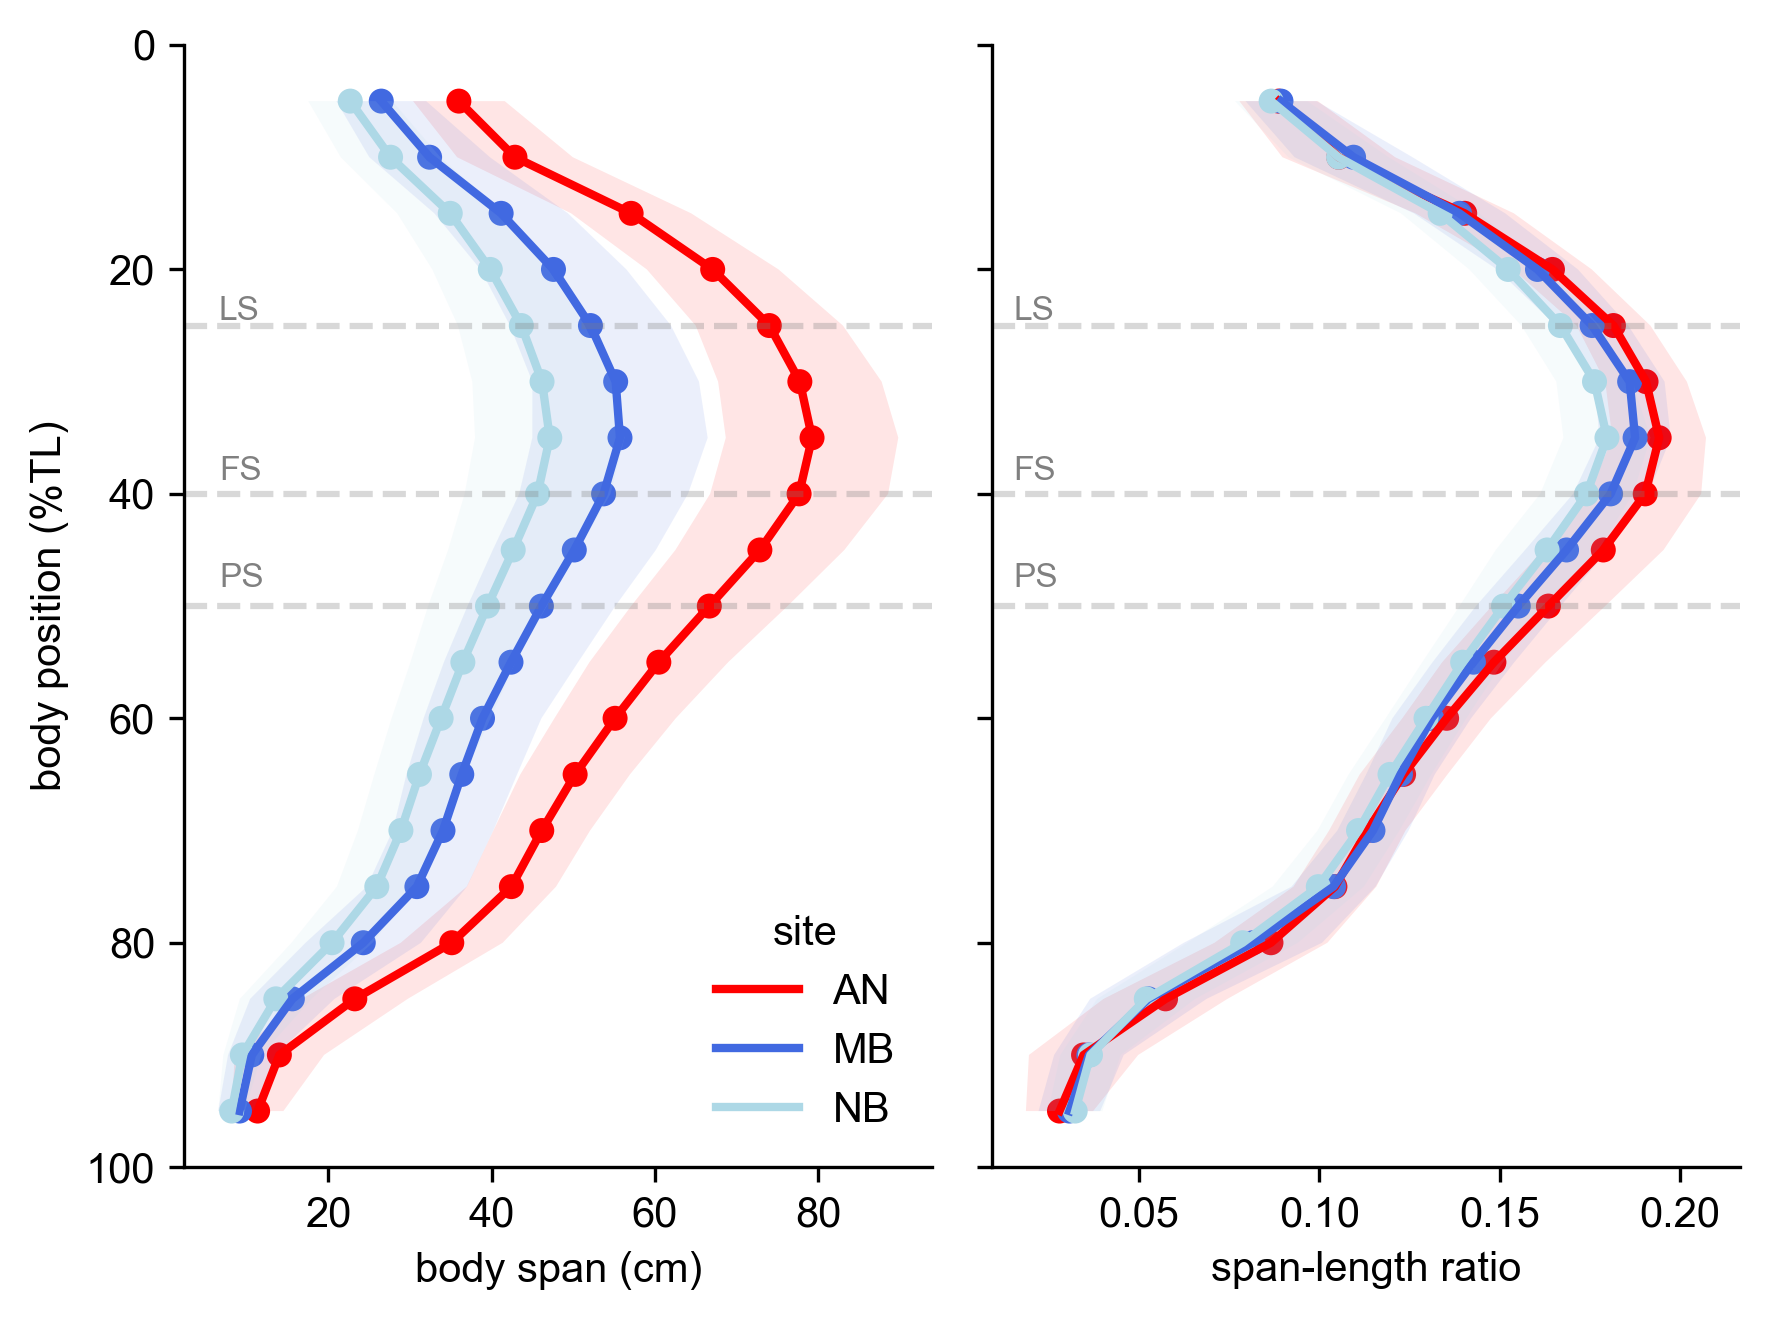

In [84]:
# --- Compute site means and std (raw spans) ---
df_site_mean_raw = df_width_id.groupby("site")[width_cols].mean()
df_site_std_raw  = df_width_id.groupby("site")[width_cols].std()

# --- Standard deviation for normalized spans ---
df_norm = df_width_id[width_cols].div(df_width_id['TL_skel_cm'], axis=0)
df_norm['site'] = df_width_id['site']

df_site_mean_norm = df_norm.groupby("site")[width_cols].mean()
df_site_std_norm  = df_norm.groupby("site")[width_cols].std()

# y axis
y_labels = [int(col.split('_')[1]) for col in width_cols]
y = np.array(y_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4.5), dpi=300, sharey=True)
plt.subplots_adjust(wspace=0.05)

# --- Panel 1: raw spans with shaded SD ---
for site in df_site_mean_raw.index:
    mean_vals = df_site_mean_raw.loc[site].values
    std_vals  = df_site_std_raw.loc[site].values
    color = site_colors.get(site, "black")
    
    # shaded ±1 SD without outline
    ax1.fill_betweenx(y, mean_vals - std_vals, mean_vals + std_vals, 
                      color=color, alpha=0.1, edgecolor='none')
    
    # mean line + dots
    ax1.plot(mean_vals, y, color=color, linewidth=2, label=site)
    ax1.scatter(mean_vals, y, color=color, edgecolors='none')

# --- Panel 2: normalized spans with shaded SD ---
for site in df_site_mean_norm.index:
    mean_vals = df_site_mean_norm.loc[site].values
    std_vals  = df_site_std_norm.loc[site].values
    color = site_colors.get(site, "black")
    
    ax2.fill_betweenx(y, mean_vals - std_vals, mean_vals + std_vals, 
                      color=color, alpha=0.1, edgecolor='none')
    ax2.plot(mean_vals, y, color=color, linewidth=2, label=site)
    ax2.scatter(mean_vals, y, color=color, edgecolors='none')


# --- Reference lines ---
ref_lines = [25, 40, 50]
ref_labels = ['LS', 'FS', 'PS']
for ax in (ax1, ax2):
    for rl, label in zip(ref_lines, ref_labels):
        ax.axhline(rl, color='gray', alpha=0.3, linestyle='--')
        ax.text(ax.get_xlim()[1]*0.07, rl*0.95, label,
                color='gray', fontsize=8, ha='left', va='center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.set_xlabel("body span (cm)")       
ax2.set_xlabel("span-length ratio")  
ax1.set_ylabel("body position (%TL)") 

yticks = sorted(set(list(ax1.get_yticks()) + [0, 100]))
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
    
ax1.invert_yaxis()
ax1.legend(title="site", loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


Fineness Ratio Exploration

/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_18562/869769533.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fr["fineness_ratio"] =  df_long["TL_skel_cm"] / df_long["span_cm"]


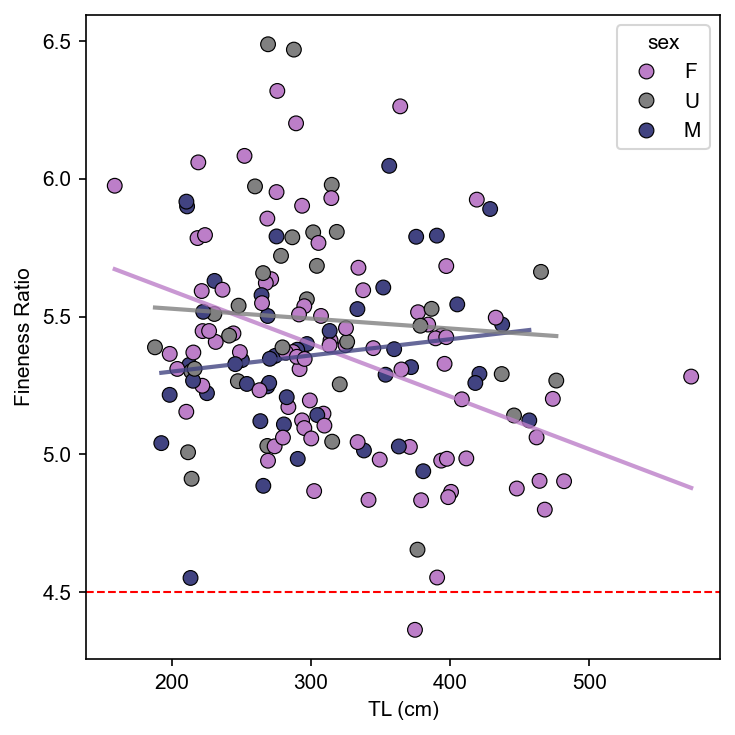

In [97]:
# extract maximum body diameter (35% TL)
df_maxd = df_long[df_long["width_percent"] == "35%"]

# create fineness ratio df
df_fr = df_maxd
df_fr["fineness_ratio"] =  df_long["TL_skel_cm"] / df_long["span_cm"]

# plot
plt.figure(figsize=(5, 5), dpi=150)

# Horizontal reference line (draw first so it's in background)
plt.axhline(
    y=4.5,
    color="red",
    linestyle="--",
    linewidth=1,
    zorder=0
)

# Scatter plot
for sex_category, color in sex_colors.items():
    subset = df_fr[df_fr["sex"] == sex_category]
    sns.regplot(
        data=subset,
        x="TL_skel_cm",
        y="fineness_ratio",
        ci=None,                  
        scatter=False,            
        line_kws={"color": color, "alpha": 0.8, "linewidth": 2}
    )

sns.scatterplot(
    data=df_fr,
    x="TL_skel_cm",
    y="fineness_ratio",
    hue="sex",              
    palette=sex_colors,      
    edgecolor="black",  
    zorder=1,
    s=50
)

plt.xlabel("TL (cm)")
plt.ylabel("Fineness Ratio")
plt.title("")

plt.tight_layout()
plt.show()

# Body Condition Ratio across Demographics
Check for TL-based differences in BSR

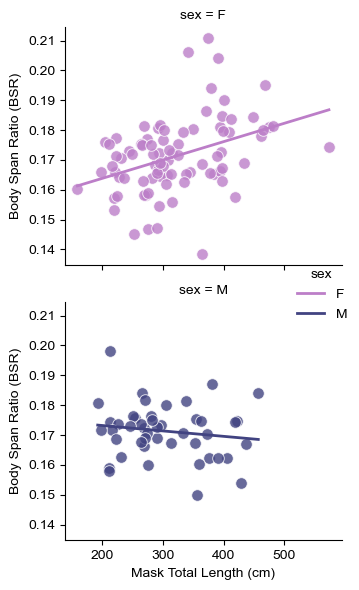

Pearson correlation for both sexes combined: r = 0.245, p-value = 0.00486
Pearson correlation for F: r = 0.387, p-value = 0.00025
Pearson correlation for M: r = -0.148, p-value = 0.327


In [62]:
g = sns.FacetGrid(df_sex, row="sex",hue="sex",palette=sex_colors,height=3, aspect=1)
g.map_dataframe(sns.scatterplot, x="TL_skel_cm", y="BSR_skel", edgecolor="w", s=70, alpha=0.8)
g.map_dataframe(sns.regplot,x="TL_skel_cm",y="BSR_skel",scatter=False,ci=None,line_kws={"lw":2})

# Labels and layout
g.set_axis_labels("Mask Total Length (cm)", "Body Span Ratio (BSR)")
g.add_legend(title="sex")
plt.tight_layout()
plt.show()

# Pearson correlations
r_value, p_value = pearsonr(df_sex['TL_skel_cm'], df_sex['BSR_skel'])
print(f"Pearson correlation for both sexes combined: r = {r_value:.3f}, p-value = {p_value:.3g}")

for sex in ['F', 'M']:
    subset = df_sex[df_sex['sex'] == sex].dropna(subset=['TL_skel_cm', 'BSR_skel'])
    r_value, p_value = pearsonr(subset['TL_skel_cm'], subset['BSR_skel'])
    print(f"Pearson correlation for {sex}: r = {r_value:.3f}, p-value = {p_value:.3g}")


In [63]:
# assumption checks
print("Normality test (Shapiro-Wilk) for ANOVA groups (sites, sexes combined):")
for site in df_sex['site'].unique():
    group = df_sex[df_sex['site'] == site]['BSR_skel'].dropna()
    if len(group) >= 3:
        stat, p = shapiro(group)
        print(f"{site}: W={stat:.3f}, p={p:.3f}")

print("\nNormality test (Shapiro-Wilk) for sex groups within sites (for t-tests):")
for site in df_sex['site'].unique():
    for sex in df_sex['sex'].unique():
        group = df_sex[(df_sex['site'] == site) & (df_sex['sex'] == sex)]['BSR_skel'].dropna()
        if len(group) >= 3:
            stat, p = shapiro(group)
            print(f"{site} - {sex}: W={stat:.3f}, p={p:.3f}")

groups = [df_sex[df_sex['site'] == site]['BSR_skel'].dropna() for site in df_sex['site'].unique()]
stat, p = levene(*groups)
print(f"Levene's test (for equal variance) acx sites: stat={stat:.3f}, p={p:.3f}")

for site in df_sex['site'].unique():
    group_m = df_sex[(df_sex['site'] == site) & (df_sex['sex'] == 'M')]['BSR_skel'].dropna()
    group_f = df_sex[(df_sex['site'] == site) & (df_sex['sex'] == 'F')]['BSR_skel'].dropna()
    stat, p = levene(group_m, group_f)
    print(f"Levene's test {site}: stat={stat:.3f}, p={p:.3f}")

Normality test (Shapiro-Wilk) for ANOVA groups (sites, sexes combined):
AN: W=0.969, p=0.434
MB: W=0.973, p=0.255
NB: W=0.959, p=0.125

Normality test (Shapiro-Wilk) for sex groups within sites (for t-tests):
AN - F: W=0.948, p=0.318
AN - M: W=0.970, p=0.894
MB - F: W=0.970, p=0.529
MB - M: W=0.963, p=0.529
NB - F: W=0.970, p=0.468
NB - M: W=0.843, p=0.047
Levene's test (for equal variance) acx sites: stat=4.290, p=0.016
Levene's test AN: stat=0.333, p=0.568
Levene's test MB: stat=1.628, p=0.208
Levene's test NB: stat=3.321, p=0.076


In [807]:
anova_bsr_acx = {}
tukey_bsr_acx = {}

# BSR differences across sites (separately for M & F)
for sex in ['M', 'F']:
    print(f"\n=== Results for sex = {sex} ===")
    df_sub = df_sex[df_sex['sex'] == sex].dropna(subset=['BSR_skel', 'site'])
    
    model = smf.ols('BSR_skel ~ C(site)', data=df_sub).fit()
    anova_results = sm.stats.anova_lm(model, typ=2)
    print(anova_results)
    anova_bsr_acx[sex] = anova_results
    
    if anova_results['PR(>F)']['C(site)'] < 0.05:
        tukey = pairwise_tukeyhsd(endog=df_sub['BSR_skel'], groups=df_sub['site'], alpha=0.05)
        print("\nTukey HSD post-hoc test:")
        print(tukey.summary())
        tukey_bsr_acx[sex] = tukey
    else:
        print("No significant site effect found.")
        tukey_bsr_acx[sex] = None


=== Results for sex = M ===
            sum_sq    df         F    PR(>F)
C(site)   0.000107   2.0  0.657163  0.523447
Residual  0.003488  43.0       NaN       NaN
No significant site effect found.

=== Results for sex = F ===
            sum_sq    df          F        PR(>F)
C(site)   0.005604   2.0  30.219374  1.471004e-10
Residual  0.007603  82.0        NaN           NaN

Tukey HSD post-hoc test:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    AN     MB  -0.0131    0.0 -0.0196 -0.0066   True
    AN     NB  -0.0209    0.0 -0.0273 -0.0145   True
    MB     NB  -0.0078 0.0049 -0.0136 -0.0021   True
----------------------------------------------------


In [808]:
ttest_bsr_within = {}

# BSR differences within site (comparing M & F)
print("\n=== Sex differences in BSR within each site ===")
for site in df_sex['site'].unique():
    group_m = df_sex[(df_sex['site'] == site) & (df_sex['sex'] == 'M')]['BSR_skel'].dropna()
    group_f = df_sex[(df_sex['site'] == site) & (df_sex['sex'] == 'F')]['BSR_skel'].dropna()

    # check if groups have enough samples
    if len(group_m) < 2 or len(group_f) < 2:
        print(f"{site}: Not enough data for t-test.")
        ttest_bsr_within[site] = None
        continue

    t_stat, p_val = ttest_ind(group_f, group_m, equal_var=True)  # or equal_var=False if variances differ
    print(f"{site}: t = {t_stat:.3f}, p = {p_val:.4f}")
    ttest_bsr_within[site] = {'t_stat': t_stat, 'p_val': p_val}


=== Sex differences in BSR within each site ===
AN: t = 3.210, p = 0.0030
MB: t = -0.674, p = 0.5036
NB: t = -1.570, p = 0.1240


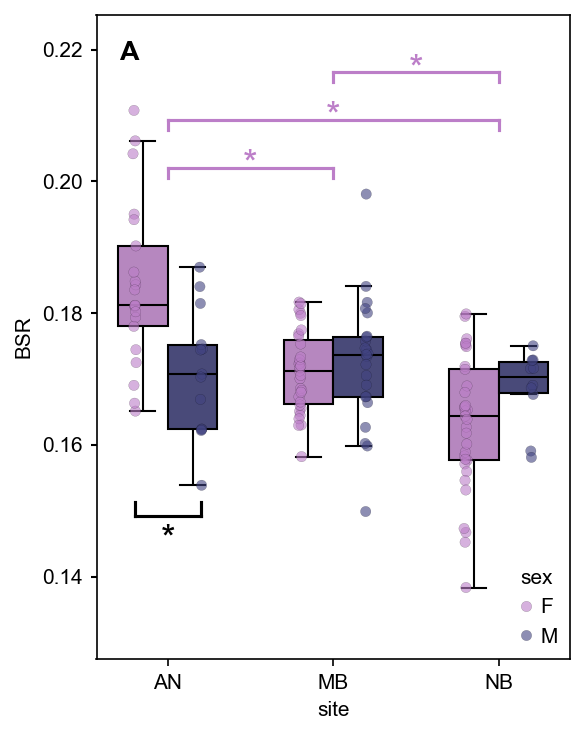

  site sex   n
0   AN   F  21
1   AN   M  13
2   MB   F  31
3   MB   M  23
4   NB   F  33
5   NB   M  10


/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_38914/3300976189.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df_sex.groupby(['site', 'sex'])['BSR_skel'].count().reset_index(name='n')


In [809]:
# force site order from high latitude to low latitude
site_order = ["AN", "MB", "NB"]
df_sex["site"] = pd.Categorical(df_sex["site"], categories=site_order, ordered=True)

plt.figure(figsize=(4, 5), dpi = 150)
ax = sns.boxplot(data=df_sex, x='site', y='BSR_skel', hue='sex',
                 palette=sex_colors, dodge=True, width=0.6, fliersize=0, 
                 boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'), 
                 capprops=dict(color='black'), medianprops=dict(color='black') )
sns.stripplot(data=df_sex, x='site', y='BSR_skel', hue='sex', palette=sex_colors,
              dodge=True, alpha=0.6, jitter=0.02, linewidth=0.1,
              edgecolor='black', size=5)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Sex')
plt.ylabel("BSR")

sites = sorted(df_sex['site'].unique())
site_positions = {site: i for i, site in enumerate(sites)}

y_max = df_sex['BSR_skel'].max()
y_min = df_sex['BSR_skel'].min()
y_range = y_max - y_min
top_margin = y_range * 0.1
bottom_margin = y_range * 0.1
plt.ylim(y_min - bottom_margin*1.5, y_max + top_margin*2)  # extra room at top for stars/lines, bottom for leg

# --- Add stars for within-site sex differences (M vs F) below plot ---
star_y_within = y_min + bottom_margin * 1.5  # just below boxes
line_height = bottom_margin * 0.3

for site, result in ttest_bsr_within.items():
    if result is None:
        continue
    p = result['p_val']
    if p < 0.05:
        x_center = site_positions[site]
        color = 'black'  # black for within-site sex difference
        
        x1 = x_center - 0.2
        x2 = x_center + 0.2
        ax.plot([x1, x2], [star_y_within, star_y_within], color=color, lw=1.5)
        ax.plot([x1, x1], [star_y_within, star_y_within + line_height], color=color, lw=1.5)
        ax.plot([x2, x2], [star_y_within, star_y_within + line_height], color=color, lw=1.5)
        ax.text(x_center, star_y_within - (line_height * 0.5), "*", ha='center', va='top', color=color, fontsize=18)

# --- Add stars and lines for across-site female differences (Tukey HSD) BELOW sex diff stars ---
if tukey_bsr_acx.get('F') is not None:
    # Start just above the top of the plot, with some vertical margin
    star_y_across = y_max - top_margin * 1.2  
    tick_height = line_height * 0.7
    star_size = 18
    female_color = sex_colors['F']

    tukey_summary = tukey_bsr_acx['F'].summary()
    for row in tukey_summary.data[1:]:
        group1, group2, meandiff, p_adj, lower, upper, reject = row
        if reject:
            x1 = site_positions[group1]
            x2 = site_positions[group2]
            x_center = (x1 + x2) / 2

            # Draw horizontal line connecting groups above boxes
            ax.plot([x1, x2], [star_y_across, star_y_across], color=female_color, lw=1.5)
            # Vertical ticks at line ends pointing downwards (since line is above)
            ax.plot([x1, x1], [star_y_across, star_y_across - tick_height], color=female_color, lw=1.5)
            ax.plot([x2, x2], [star_y_across, star_y_across - tick_height], color=female_color, lw=1.5)
            # Draw star above the center line
            ax.text(x_center, star_y_across - tick_height * 1.5, "*", ha='center', va='bottom', color=female_color, fontsize=star_size)

            # Move up for the next pair so they don't overlap
            star_y_across += top_margin * 1.0

ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='both', length=3, width=1, color='black', direction='out')
ax.text(0.09, 0.96, 'A', transform=ax.transAxes,
             fontsize=13, fontweight='bold', va='top', ha='right')

leg = plt.legend(by_label.values(), by_label.keys(), title='sex',
                 loc='lower right', borderaxespad=0.2,
                 handlelength=1, handletextpad=0.2, 
                 columnspacing=0.3,frameon=False)   

plt.tight_layout()
plt.show()

summary_table = df_sex.groupby(['site', 'sex'])['BSR_skel'].count().reset_index(name='n')
print(summary_table)

### Age Class

In [810]:
age_categories = ['juvenile', 'subadult', 'adult']

In [811]:
ttest_sex_by_ageclass = {}

for ageclass in df_sex['ageclass'].cat.categories:
    df_sub = df_sex[df_sex['ageclass'] == ageclass].dropna(subset=['BSR_skel', 'sex'])
    
    males = df_sub[df_sub['sex'] == 'M']['BSR_skel']
    females = df_sub[df_sub['sex'] == 'F']['BSR_skel']
    
    if len(males) > 1 and len(females) > 1:
        t_stat, p_val = ttest_ind(males, females, equal_var=False)
        ttest_sex_by_ageclass[ageclass] = {'t_stat': t_stat, 'p_val': p_val}
    else:
        ttest_sex_by_ageclass[ageclass] = None  # Not enough data
    
# Check results
for ageclass, result in ttest_sex_by_ageclass.items():
    if result is not None:
        print(f"Sex difference in BSR for ageclass {ageclass}: p = {result['p_val']:.4f}")
    else:
        print(f"Not enough data to test sex difference for ageclass {ageclass}")

Sex difference in BSR for ageclass juvenile: p = 0.0081
Sex difference in BSR for ageclass subadult: p = 0.2199
Sex difference in BSR for ageclass adult: p = 0.0162


In [812]:
# BSR differences across age class (separating M & F)
tukey_ageclass_across = {}

for sex in df_sex['sex'].unique():
    print(f"\nANOVA for BSR ~ ageclass in sex = {sex}")
    df_sub = df_sex[df_sex['sex'] == sex].dropna(subset=['BSR_skel', 'ageclass'])
    
    model = smf.ols('BSR_skel ~ C(ageclass)', data=df_sub).fit()
    anova_results = anova_lm(model, typ=2)
    print(anova_results)
    
    if anova_results.loc['C(ageclass)', 'PR(>F)'] < 0.05:
        tukey = pairwise_tukeyhsd(endog=df_sub['BSR_skel'], groups=df_sub['ageclass'], alpha=0.05)
        print(tukey.summary())
        tukey_ageclass_across[sex] = tukey
    else:
        tukey_ageclass_across[sex] = None


ANOVA for BSR ~ ageclass in sex = F
               sum_sq    df         F    PR(>F)
C(ageclass)  0.001988   2.0  7.264165  0.001246
Residual     0.011220  82.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
   adult juvenile  -0.0151 0.0113 -0.0273 -0.0029   True
   adult subadult   -0.007 0.3626 -0.0193  0.0052  False
juvenile subadult   0.0081 0.0078  0.0018  0.0144   True
--------------------------------------------------------

ANOVA for BSR ~ ageclass in sex = M
               sum_sq    df         F    PR(>F)
C(ageclass)  0.000088   2.0  0.542302  0.585333
Residual     0.003506  43.0       NaN       NaN


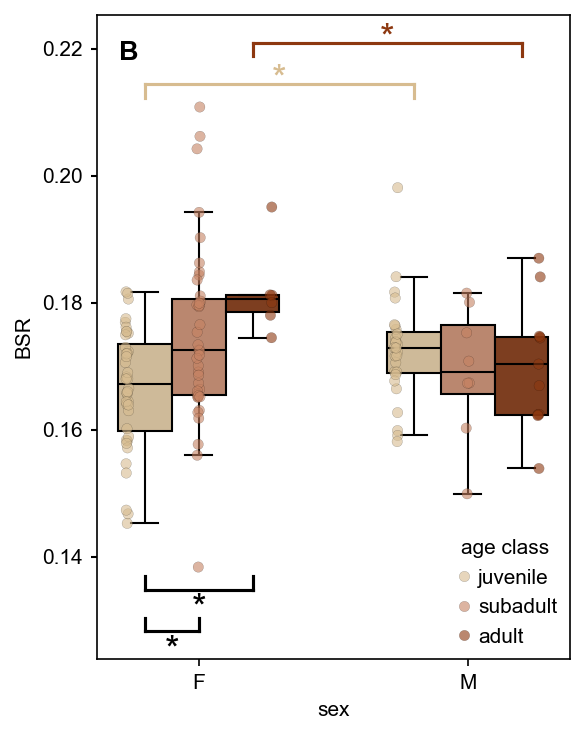

   ageclass sex   n
0  juvenile   F  40
1  juvenile   M  27
2  subadult   F  39
3  subadult   M   8
4     adult   F   6
5     adult   M  11


/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_38914/2283758400.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df_sex.groupby(['ageclass', 'sex'])['BSR_skel'].count().reset_index(name='n')


In [ ]:
plt.figure(figsize=(4, 5), dpi=300)

ax = sns.boxplot(data=df_sex, x='sex', y='BSR_skel', hue='ageclass',
                 palette=age_colors, dodge=True, width=0.6, fliersize=0, 
                 boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'), 
                 capprops=dict(color='black'), medianprops=dict(color='black'))
sns.stripplot(data=df_sex, x='sex', y='BSR_skel', hue='ageclass',
              palette=age_colors, dodge=True, alpha=0.6, jitter=0.02,
              linewidth=0.1, edgecolor='black', size=5)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.ylabel("BSR")

sex_categories = sorted(df_sex['sex'].unique())
sex_positions = {sex: i for i, sex in enumerate(sex_categories)}

y_max = df_sex['BSR_skel'].max()
y_min = df_sex['BSR_skel'].min()
y_range = y_max - y_min
top_margin = y_range * 0.1
bottom_margin = y_range * 0.1
plt.ylim(y_min - bottom_margin*2.0, y_max + top_margin*2)  # extra room at top for stars/lines, bottom for leg

box_width = 0.6
num_age = len(age_categories)
dodge_offset = box_width / num_age
age_offsets = {age: (i - (num_age - 1)/2) * dodge_offset for i, age in enumerate(age_categories)}

line_height = y_range * 0.03
star_size = 18

# --- Stars for within-sex age class differences (below boxes, black) ---
for sex in sex_categories:
    tukey = tukey_ageclass_across.get(sex)
    if tukey is None:
        continue

    tukey_summary = tukey.summary()
    star_y = y_min - bottom_margin * 0.5  # below plot

    for row in tukey_summary.data[1:]:
        group1, group2, meandiff, p_adj, lower, upper, reject = row
        if reject:
            x1 = sex_positions[sex] + age_offsets[group1]
            x2 = sex_positions[sex] + age_offsets[group2]
            x_center = (x1 + x2) / 2

            ax.plot([x1, x2], [star_y, star_y], color='black', lw=1.5)
            ax.plot([x1, x1], [star_y, star_y + line_height], color='black', lw=1.5)
            ax.plot([x2, x2], [star_y, star_y + line_height], color='black', lw=1.5)
            ax.text(x_center, star_y - line_height * 0.2, "*", ha='center', va='top', color='black', fontsize=star_size)

            star_y -= line_height * 3  # stack stars downwards

# --- Stars for across-sex differences per age class (above boxes, colored by ageclass) ---
star_y = y_max + top_margin*0.5  # initialize starting y-position below plot
for ageclass in age_categories:
    res = ttest_sex_by_ageclass.get(ageclass)
    if res is not None and res['p_val'] < 0.05:
        x_female = sex_positions['F'] + age_offsets[ageclass]
        x_male = sex_positions['M'] + age_offsets[ageclass]
        x_center = (x_female + x_male) / 2

        color = age_colors[ageclass]

        # horizontal and vertical lines
        ax.plot([x_female, x_male], [star_y, star_y], color=color, lw=1.5)
        ax.plot([x_female, x_female], [star_y, star_y - line_height], color=color, lw=1.5)
        ax.plot([x_male, x_male], [star_y, star_y - line_height], color=color, lw=1.5)

        # star
        ax.text(x_center, star_y + line_height *-1, "*", ha='center', va='bottom', color=color, fontsize=star_size)

        # stack the next star higher
        star_y += line_height * 3


ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='both', length=3, width=1, color='black', direction='out')
ax.text(0.09, 0.96, 'B', transform=ax.transAxes,
             fontsize=13, fontweight='bold', va='top', ha='right')

plt.legend(by_label.values(), by_label.keys(), title='age class',
           loc='lower right', borderaxespad=0.2,
           handlelength=1, handletextpad=0.2, columnspacing=0.3, frameon=False)

plt.tight_layout()

# show plot
plt.show()

summary_table = df_sex.groupby(['ageclass', 'sex'])['BSR_skel'].count().reset_index(name='n')
print(summary_table)

# Comparison to other metrics

In [814]:
# summarize all metrics
cols = ['BSR_skel', 'BAI_skel', 'ASC_skel']

# compute mean, std, min, max for each column
summary = df[cols].agg(['mean', 'std', 'min', 'max']).T  # transpose so columns are stats
summary['range'] = summary['max'] - summary['min']

# optional: reset index to have a clean column for metric names
summary = summary.reset_index().rename(columns={'index':'metric'})
summary

,metric,mean,std,min,max,range
0,BSR_skel,0.170355,0.011719,0.138351,0.210788,0.072438
1,BAI_skel,13.501517,1.054636,10.902132,17.583187,6.681056
2,ASC_skel,1.022039,0.072588,0.831482,1.274460,0.442978


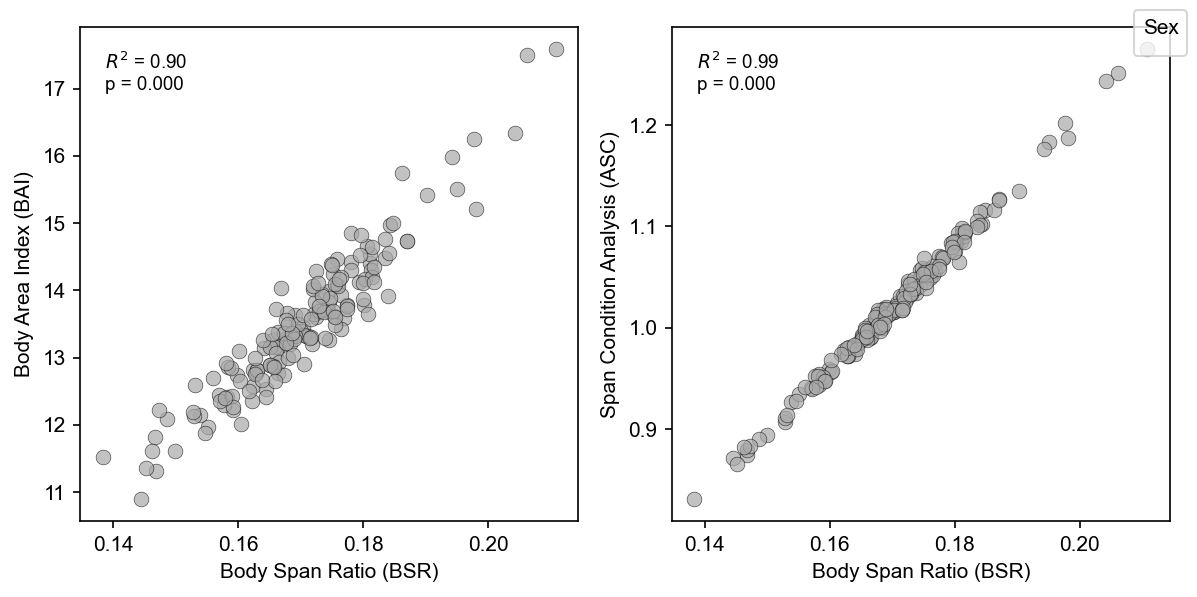

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300, sharex=True, sharey=False)

# BSR vs BAI
sns.scatterplot(
    data=df, x="BSR_skel", y="BAI_skel", alpha=0.7, color = "darkgrey",
    edgecolor="black", linewidth=0.3, s=50, ax=axes[0])
axes[0].set_xlabel("Body Span Ratio (BSR)")
axes[0].set_ylabel("Body Area Index (BAI)")

r_bai, p_bai = pearsonr(df["BSR_skel"], df["BAI_skel"])
r2_bai = r_bai**2
axes[0].text(0.05, 0.95, f"$R^2$ = {r2_bai:.2f}\np = {p_bai:.3f}",
             transform=axes[0].transAxes, ha="left", va="top",
             fontsize=9, bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

# BSR vs ASC
sns.scatterplot(
    data=df, x="BSR_skel", y="ASC_skel", alpha=0.7, color = "darkgrey",
    edgecolor="black", linewidth=0.3, s=50, ax=axes[1])
axes[1].set_xlabel("Body Span Ratio (BSR)")
axes[1].set_ylabel("Span Condition Analysis (ASC)")

r_asc, p_asc = pearsonr(df["BSR_skel"], df["ASC_skel"])
r2_asc = r_asc**2
axes[1].text(0.05, 0.95, f"$R^2$ = {r2_asc:.2f}\np = {p_asc:.3f}",
             transform=axes[1].transAxes, ha="left", va="top",
             fontsize=9, bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

# Handle legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), title="Sex", loc="upper right")

plt.tight_layout()
plt.show()


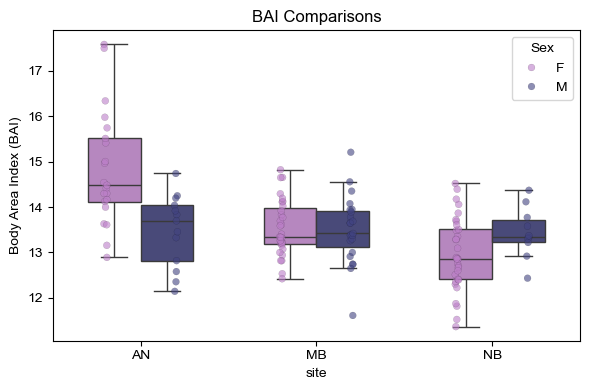

In [816]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_sex,x='site',y='BAI_skel',hue='sex',palette=sex_colors,dodge=True,width=0.6,fliersize=0)
sns.stripplot(data=df_sex, x='site', y='BAI_skel', hue='sex', palette=sex_colors, dodge=True, alpha=0.6,jitter=0.02, 
              linewidth=0.1, edgecolor='black', size=5)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Sex')
plt.ylabel("Body Area Index (BAI)")
plt.title("BAI Comparisons")
plt.tight_layout()
plt.show()

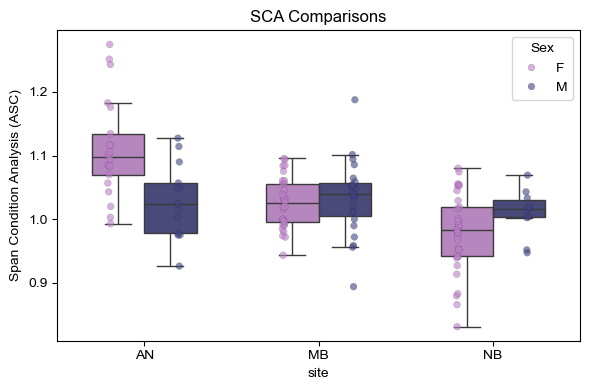

In [817]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_sex,x='site',y='ASC_skel',hue='sex',palette=sex_colors,dodge=True,width=0.6,fliersize=0)
sns.stripplot(data=df_sex, x='site', y='ASC_skel', hue='sex', palette=sex_colors, dodge=True, alpha=0.6,jitter=0.02, 
              linewidth=0.1, edgecolor='black', size=5)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Sex')
plt.ylabel("Span Condition Analysis (ASC)")
plt.title("SCA Comparisons")
plt.tight_layout()
plt.show()